## Imports and Configuration

In [18]:
import numpy as np
import matplotlib.pyplot as plt

import pickle as pk
import sailfish
import matplotlib.colors as mcolors
from matplotlib.patches import Circle, Patch
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D
import cmocean, cmasher
import glob, os, pickle, sys
from concurrent.futures import ProcessPoolExecutor
from functools import partial
from scipy.ndimage import rotate as nd_rotate
from scipy.signal import lombscargle
from scipy.stats import binned_statistic


from sailfish.physics.cooling import ShakuraSunyaevDisk, cgs, PlanckSpectrum
from sailfish.physics.kepler import OrbitalState, PointMass
from Diagnostics import DavidTimeseries, eccentric_anomaly
transparent_black = mcolors.LinearSegmentedColormap.from_list("transparent_black", [(0, (1, 1, 1, 0)), (1, (0, 0, 0, 1))])

text_width   = 5.0 #6.8
column_width = 2.4 #3.3
def configure_matplotlib():
    plt.rc('xtick' , labelsize=8)
    plt.rc('ytick' , labelsize=8)
    plt.rc('axes'  , labelsize=8)
    plt.rc('legend', fontsize=8)
    plt.rc('font', family='DejaVu Sans', size=8)
    plt.rc('text', usetex=True)
    plt.rcParams.update({
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 5,
        "ytick.major.size": 5,
        "xtick.major.width": 2,
        "ytick.major.width": 2,
        "xtick.color": "black",
        "ytick.color": "black",
    })
    plt.rcParams.update({
        "axes.linewidth": 2,  # default is 0.8
    })
configure_matplotlib()

def SaveBinStats(dictname, keys, args):
    for (key, arg) in zip(keys, args):
        dictname[key].append(arg)

def load_checkpoint(filename, require_solver=None):
    with open(filename, "rb") as f:
        chkpt = pk.load(file=f)
    return chkpt

def ViscousTime(r, Mach, alpha):
    return (5/24/np.pi) * (r**1.6) * Mach**2 / alpha

def EstimateViscousTime(r, Mach, alpha):
    Omega_b  = 1.0
    Period_b = 2 * np.pi / Omega_b
    Omega_k  = Omega_b * r**(-1.5)
    nu       = alpha * r**2 * Omega_k / (Mach**2)
    t_nu     = 2 * r**2 / (3 * nu)
    return t_nu / (2 * np.pi)

def bullseye_scatter(ax, x, y, marker='o', color='C0', size=5, 
                     inner_fraction=0.5, zorder=3, label=None, **kwargs):
    """
    Scatter with a colored outer marker and white inner marker.
    inner_fraction: area of inner marker relative to outer (0.3 → inner radius ~55% of outer)
    """
    ax.scatter(x, y, s=size,                  marker=marker, color=color,
               zorder=zorder,     label=label, **kwargs)
    ax.scatter(x, y, s=size * inner_fraction, marker=marker, color='white',
               zorder=zorder + 1,             **kwargs)

def EddingtonFraction(Mach, M, r, gamma=5/3, alpha=0.1, eta=0.1):
    kappa_es = 0.4 # in cgs
    rg       = cgs['G'] * M / cgs['c'] / cgs['c']
    c1       = np.sqrt(4 * cgs['sigmab'] * kappa_es * cgs['c']**2 * cgs['mp']**4 / (cgs['kb']**4) / 3)
    c2       = (0.1**0.5) * (5/3)**(-2) * (2530*rg)**(-0.25) * (cgs['G'] * 8e6*cgs['msun'])**0.75 * 1e-5 * 0.1
    print('Eddington Fraction (Coefficient): ', c1 * c2/np.sqrt(2))
    return c1 * c2 * (alpha/0.1)**0.5 * (gamma/(5/3))**(-2) * (r/(2530))**(-0.25) * (M/(8e6*cgs['msun']))**0.75 * (Mach/10)**(-5) * (eta/0.1) / np.sqrt(2)

print('Viscous time : ',ViscousTime(r=2.0, Mach=40, alpha=0.1))


Viscous time :  3216.450451818739


## Disk Remapping Parameters

In [2]:
Mach10_Remapping = ShakuraSunyaevDisk(
    central_mass_msun = 8e6, 
    length_scale_pc   = 9.7e-4,
    mach_number_a     = 10,
    alpha             = 0.1,
    gamma             = 5./3.,
    target_accretion_rate=0.1,
).Mdrop

Mach20_Remapping = ShakuraSunyaevDisk(
    central_mass_msun = 8e6, 
    length_scale_pc   = 9.7e-4,
    mach_number_a     = 20,
    alpha             = 0.1,
    gamma             = 5./3.,
    target_accretion_rate=0.1,
).Mdrop

Mach40_Remapping = ShakuraSunyaevDisk(
    central_mass_msun = 8e6, 
    length_scale_pc   = 9.7e-4,
    mach_number_a     = 40,
    alpha             = 0.1,
    gamma             = 5./3.,
    target_accretion_rate=0.1,
).Mdrop

Mach80_Remapping = ShakuraSunyaevDisk(
    central_mass_msun = 8e6, 
    length_scale_pc   = 9.7e-4,
    mach_number_a     = 80,
    alpha             = 0.1,
    gamma             = 5./3.,
    target_accretion_rate=0.1,
).Mdrop

Mach160_Remapping = ShakuraSunyaevDisk(
    central_mass_msun = 8e6, 
    length_scale_pc   = 9.7e-4,
    mach_number_a     = 160,
    alpha             = 0.1,
    gamma             = 5./3.,
    target_accretion_rate=0.1,
).Mdrop

print('=== Rescaling values from simulated disk to implied Eddington ratio of 0.1 ===')
print('-----------------+-----------------------------------------------------------+')
print('                 | Mach 10   |  Mach 20  |  Mach 40  |  Mach 80  |  Mach 160 |')
print('-----------------+-----------------------------------------------------------+')
print(f"Mdrop values     | {Mach10_Remapping:.3e} | {Mach20_Remapping:.3e} | {Mach40_Remapping:.3e} | {Mach80_Remapping:.3e} | {Mach160_Remapping:.3e} |")
print(f"A values         | {1/Mach10_Remapping:.3e} | {1/Mach20_Remapping:.3e} | {1/Mach40_Remapping:.3e} | {1/Mach80_Remapping:.3e} | {1/Mach160_Remapping:.3e} |")

=== Rescaling values from simulated disk to implied Eddington ratio of 0.1 ===
-----------------+-----------------------------------------------------------+
                 | Mach 10   |  Mach 20  |  Mach 40  |  Mach 80  |  Mach 160 |
-----------------+-----------------------------------------------------------+
Mdrop values     | 6.456e-08 | 2.066e-06 | 6.611e-05 | 2.116e-03 | 6.770e-02 |
A values         | 1.549e+07 | 4.840e+05 | 1.513e+04 | 4.727e+02 | 1.477e+01 |


## Density Map Colour Schemes

In [3]:
data        = {}
dir         = '/mnt/beegfs/haimagrp/david_oneill/sailfish/Retrograde/'
Checkpoints = ['Fixed_e/e00Mach10/chkpt.0240.pk', 'Fixed_e/e03Mach10/chkpt.0240.pk', 'Fixed_e/e06Mach10/chkpt.0240.pk',
               'Fixed_e/e00Mach20/chkpt.0085.pk', 'Fixed_e/e03Mach20/chkpt.0085.pk', 'Fixed_e/e06Mach20/chkpt.0085.pk',
               'Fixed_e/e00Mach40/chkpt.0700.pk', 'Fixed_e/e03Mach40/chkpt.0400.pk', 'Fixed_e/e06Mach40/chkpt.0500.pk']
Names       = ['M10_e00'                , 'M10_e03'                , 'M10_e06',
               'M20_e00'                , 'M20_e03'                , 'M20_e06',
               'M40_e00'                , 'M40_e03'                , 'M40_e06']

# e00Mach10, e03Mach10, e06Mach10: Close to unity, ell0=0 and density maps clear
# All Mach 20 need to be rerun (ASTRO Currently)
# e00Mach40, 

for index in range(0, len(Checkpoints)):
    data[Names[index]] = load_checkpoint(dir + Checkpoints[index])


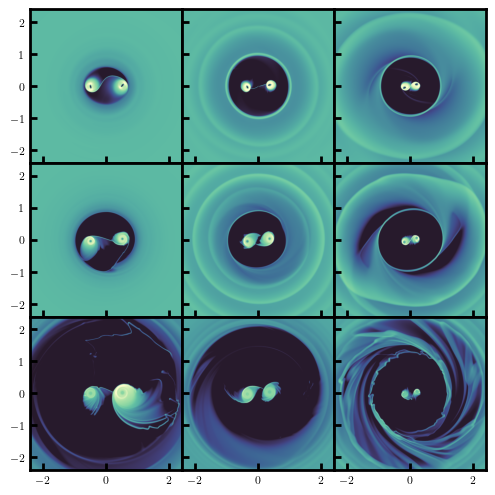

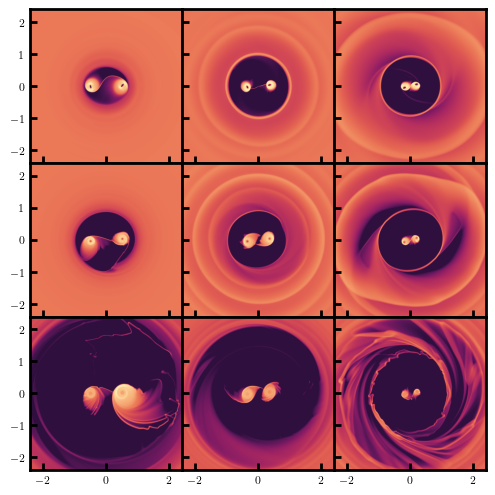

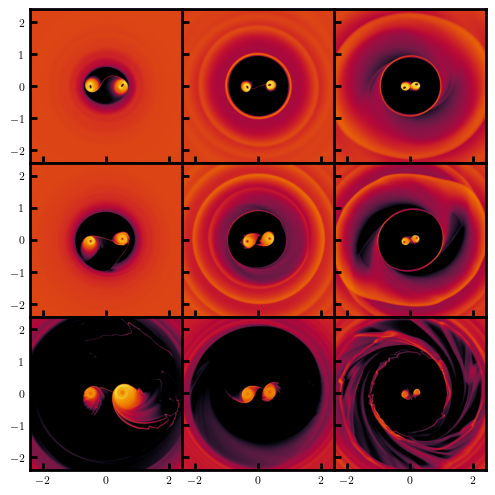

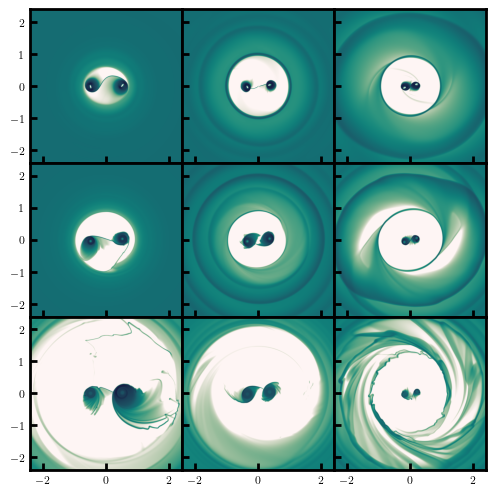

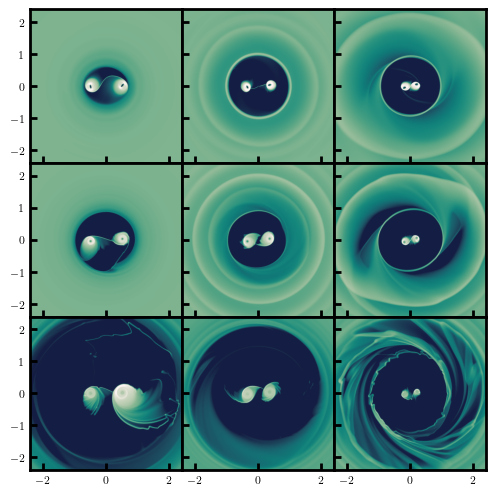

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(text_width, text_width), dpi=100,
                         sharex=True, sharey=True,
                         height_ratios=[0.33, 0.33, 0.33],
                         gridspec_kw={'hspace': 0.0, 'wspace': 0.0})
axes_flat = axes.flatten()


for index in range(0, len(Checkpoints)):
    ax     = axes_flat[index]
    chkpt  = data[Names[index]]
    Mdrop  = chkpt['SS73'].Mdrop
    Sigma  = chkpt["solution"][:, :, 0].T  * Mdrop**(3./5.)
    mesh   = chkpt["mesh"]
    extent = mesh.x0, mesh.x1, mesh.y0, mesh.y1
    cm     = ax.imshow(
                    np.log10(Sigma),
                    origin="lower",
                    vmin=-7,
                    vmax=-4,
                    cmap=cmocean.cm.deep_r,
                    extent=extent
                    )
    ax.set_xlim(-2.4, 2.4)
    ax.set_ylim(-2.4, 2.4)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    ax.set_aspect('auto')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(3, 3, figsize=(text_width, text_width), dpi=100,
                         sharex=True, sharey=True,
                         height_ratios=[0.33, 0.33, 0.33],
                         gridspec_kw={'hspace': 0.0, 'wspace': 0.0})
axes_flat = axes.flatten()


for index in range(9):
    ax     = axes_flat[index]
    chkpt  = data[Names[index]]
    Mdrop  = chkpt['SS73'].Mdrop
    Sigma  = chkpt["solution"][:, :, 0].T  * Mdrop**(3./5.)
    mesh   = chkpt["mesh"]
    extent = mesh.x0, mesh.x1, mesh.y0, mesh.y1
    cm     = ax.imshow(
                    np.log10(Sigma),
                    origin="lower",
                    vmin=-7,
                    vmax=-4,
                    cmap=cmocean.cm.matter_r,
                    extent=extent
                    )
    ax.set_xlim(-2.4, 2.4)
    ax.set_ylim(-2.4, 2.4)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    ax.set_aspect('auto')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 3, figsize=(text_width, text_width), dpi=100,
                         sharex=True, sharey=True,
                         height_ratios=[0.33, 0.33, 0.33],
                         gridspec_kw={'hspace': 0.0, 'wspace': 0.0})
axes_flat = axes.flatten()


for index in range(9):
    ax     = axes_flat[index]
    chkpt  = data[Names[index]]
    Mdrop  = chkpt['SS73'].Mdrop
    Sigma  = chkpt["solution"][:, :, 0].T  * Mdrop**(3./5.)
    mesh   = chkpt["mesh"]
    extent = mesh.x0, mesh.x1, mesh.y0, mesh.y1
    cm     = ax.imshow(
                    np.log10(Sigma),
                    origin="lower",
                    vmin=-6.7,
                    vmax=-4,
                    cmap=cmasher.ember,
                    extent=extent
                    )
    ax.set_xlim(-2.4, 2.4)
    ax.set_ylim(-2.4, 2.4)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    ax.set_aspect('auto')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 3, figsize=(text_width, text_width), dpi=100,
                         sharex=True, sharey=True,
                         height_ratios=[0.33, 0.33, 0.33],
                         gridspec_kw={'hspace': 0.0, 'wspace': 0.0})
axes_flat = axes.flatten()


for index in range(9):
    ax     = axes_flat[index]
    chkpt  = data[Names[index]]
    Mdrop  = chkpt['SS73'].Mdrop
    Sigma  = chkpt["solution"][:, :, 0].T  * Mdrop**(3./5.)
    mesh   = chkpt["mesh"]
    extent = mesh.x0, mesh.x1, mesh.y0, mesh.y1
    cm     = ax.imshow(
                    np.log10(Sigma),
                    origin="lower",
                    vmin=-7,
                    vmax=-4,
                    cmap=cmocean.cm.tempo,
                    extent=extent
                    )
    ax.set_xlim(-2.4, 2.4)
    ax.set_ylim(-2.4, 2.4)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    ax.set_aspect('auto')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 3, figsize=(text_width, text_width), dpi=100,
                         sharex=True, sharey=True,
                         height_ratios=[0.33, 0.33, 0.33],
                         gridspec_kw={'hspace': 0.0, 'wspace': 0.0})
axes_flat = axes.flatten()


for index in range(9):
    ax     = axes_flat[index]
    chkpt  = data[Names[index]]
    Mdrop  = chkpt['SS73'].Mdrop
    Sigma  = chkpt["solution"][:, :, 0].T  * Mdrop**(3./5.)
    mesh   = chkpt["mesh"]
    extent = mesh.x0, mesh.x1, mesh.y0, mesh.y1
    cm     = ax.imshow(
                    np.log10(Sigma),
                    origin="lower",
                    vmin=-7,
                    vmax=-4,
                    cmap=cmocean.cm.tempo_r,
                    extent=extent
                    )
    ax.set_xlim(-2.4, 2.4)
    ax.set_ylim(-2.4, 2.4)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    ax.set_aspect('auto')

plt.tight_layout()
plt.show()


/tmp/ipykernel_763845/2391595747.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


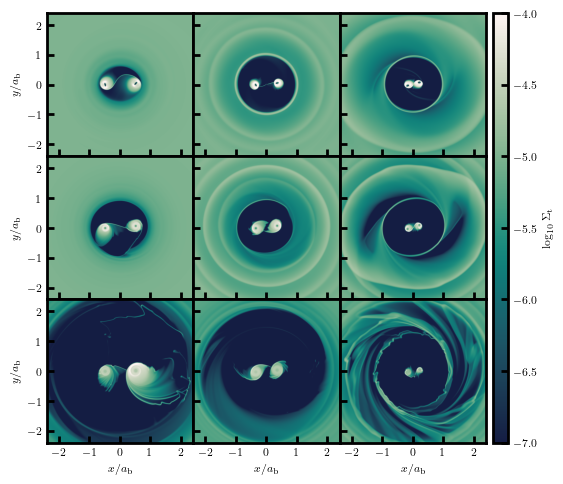

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(text_width, 0.97*text_width), dpi=100,
                         sharex=True, sharey=True,
                         height_ratios=[0.33, 0.33, 0.33],
                         gridspec_kw={'hspace': 0.0, 'wspace': 0.0})
axes_flat = axes.flatten()


def VMap(ax, mesh, Radius, Vx, Vy, Number_of_Vectors=10):
    x = np.array([mesh.cell_coordinates(i, 0)[0] for i in range(mesh.shape[0])])
    y = np.array([mesh.cell_coordinates(0, j)[1] for j in range(mesh.shape[1])])

    try:
        rescaled_x = [ix for ix in x if np.abs(ix) < Radius]
        xmin, xmax = np.where(x == np.min(rescaled_x))[0][0], np.where(x == np.max(rescaled_x))[0][0]
    except:
        rescaled_x = x
        xmin, xmax = 0,len(x)-1

    Sampling = (xmax-xmin)//Number_of_Vectors

    if len(rescaled_x)//Number_of_Vectors == 0:
        Sampling = 1

    X, Y       = np.meshgrid(x[xmin:xmax:Sampling], y[xmin:xmax:Sampling])

    Vx_sampled = Vx[xmin:xmax:Sampling, xmin:xmax:Sampling] 
    Vy_sampled = Vy[xmin:xmax:Sampling, xmin:xmax:Sampling]
    ax.quiver(X, Y, Vx_sampled, Vy_sampled, width=0.006, angles='xy', scale_units='xy', scale=8, color = 'silver', headlength=3, headaxislength=2.,)


for index in range(9):
    ax     = axes_flat[index]
    chkpt  = data[Names[index]]

    mesh   = chkpt["mesh"]
    SS73   = chkpt["SS73"]
    Sigma  = chkpt["solution"][:, :, 0].T * SS73.Mdrop**(3./5.)
    Vx     = chkpt["solution"][:, :, 1].T
    Vy     = chkpt["solution"][:, :, 2].T

    extent = mesh.x0, mesh.x1, mesh.y0, mesh.y1
    cm     = ax.imshow(
                    np.log10(Sigma),
                    origin="lower",
                    vmin=-7.0,
                    vmax=-4.0,
                    cmap=cmocean.cm.tempo_r,
                    extent=extent
                    )
    ax.set_xlim(-2.4, 2.4)
    ax.set_ylim(-2.4, 2.4)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    ax.set_aspect('auto')
    #VMap(ax=ax, mesh=mesh, Radius=2.4, Vx=Vx, Vy=Vy, Number_of_Vectors=12)

cax = inset_axes(axes[1, 2],  # anchor to middle-right panel
                 width="10%",
                 height="300%",  # spans 3 panels
                 loc="center right",
                 bbox_to_anchor=(0.15, 0, 1, 1),
                 bbox_transform=axes[1, 2].transAxes,
                 borderpad=0)

for ax in axes_flat:
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_major_locator(MultipleLocator(1))

cbar = fig.colorbar(cm, cax=cax)
cbar.set_label(r'$\log_{10} \Sigma_\mathrm{t}$')
col_labels = [r'$x / a_\mathrm{b}$', r'$x / a_\mathrm{b}$', r'$x / a_\mathrm{b}$']
row_labels = [r'$y / a_\mathrm{b}$', r'$y / a_\mathrm{b}$', r'$y / a_\mathrm{b}$']

for col in range(3):
    axes[2, col].set_xlabel(col_labels[col])

for row in range(3):
    axes[row, 0].set_ylabel(row_labels[row])


plt.tight_layout()
plt.savefig('DensityMaps.png', dpi = 400, bbox_inches='tight')

# Sweep Plotting

### Orbital Evolution and EM Emission from the disk sweep simulations

In [ ]:
def ComputeBinnedStats(times, field, Averaging_Window):
    """Return bin centers, means, and 1-sigma standard deviations."""
    t_min, t_max = np.min(times), np.max(times)
    num_bins    = int(np.ceil((t_max - t_min) / Averaging_Window))
    bin_edges   = np.linspace(t_min, t_max, num_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_means   = np.zeros(num_bins)
    bin_stds    = np.zeros(num_bins)

    for i in range(num_bins):
        bin_mask = (times >= bin_edges[i]) & (times < bin_edges[i + 1])
        bin_data = field[bin_mask]
        if len(bin_data) > 1:
            bin_means[i] = np.mean(bin_data)
            bin_stds[i]  = np.std(bin_data)
        elif len(bin_data) == 1:
            bin_means[i] = bin_data[0]
            bin_stds[i]  = np.nan
        else:
            bin_means[i] = np.nan
            bin_stds[i]  = np.nan

    return bin_centers, bin_means, bin_stds


def ComputeAdotEdot(checkpoint):
    ts                  = DavidTimeseries(checkpoint)
    SS73                = ts.SS73
    M_dot_0             = SS73.Mdot_inf
    mask                = np.array(ts.eccentricity) > 0.0001
    t_arr               = np.array(ts.time)[mask]          # actual orbit times
    e                   = np.array(ts.eccentricity)[mask]
    a                   = np.array(ts.semimajor_axis)[mask]

    primary, secondary  = ts.pointmasses
    m1, m2              = primary.mass, secondary.mass
    M, G                = m1 + m2, 1.0                                          # mass ratio
    mu                  = m1 * m2 / M                                        # reduced mass
    
    n          = len(t_arr)
    Torque     = -(np.array(ts.torque_g[-n:]) + np.array(ts.torque_a[-n:])) / M_dot_0
    Power      = -(np.array(ts.power_g[-n:])  + np.array(ts.power_a[-n:]))  / M_dot_0
    Accretion_1 = -(np.array(ts.mdot1[-n:])) / M_dot_0
    Accretion_2 = -(np.array(ts.mdot2[-n:])) / M_dot_0
    Mdot        = Accretion_1 + Accretion_2
    #Mdot        = np.ones_like(Accretion_2)

    E_Anomaly  = np.array([eccentric_anomaly(2*np.pi*t_arr[i], e[i], a[i], M) for i in range(n)])
    r_binary   = a * (1 - e * np.cos(E_Anomaly))
    E_orb      = -G * M * mu / (2 * a)
    L          = mu * np.sqrt(G * M * a * (1 - e**2))

    adot = (Mdot/M) * (1 - 2*a/r_binary) - Power/E_orb
    edot = ((1-e**2)/(e+1e-5)) * ((Mdot/M)*(1-a/r_binary) - Power/(2*E_orb) - Torque/L)
    return e, adot, edot, Mdot


def ComputeLightcurves(checkpoint):
    ts                  = DavidTimeseries(checkpoint)
    SS73                = ts.SS73
    M_dot_0             = SS73.Mdot_inf
    n_final             = len(ts.eccentricity[ts.eccentricity > 0.0001])
    t_orbits            = np.array(ts.time[-n_final:])          # orbit count — correct time axis for LS

    return (
        ts.infared[-n_final:] / M_dot_0,
        ts.optical[-n_final:] / M_dot_0,
        ts.uv[-n_final:]      / M_dot_0,
        t_orbits
    )

Mach10Sweep   = load_checkpoint('/mnt/beegfs/haimagrp/david_oneill/sailfish/Retrograde/Sweeps/Mach10/n4000/chkpt.0450.pk')
Mach20Sweep_a = load_checkpoint('/mnt/beegfs/haimagrp/david_oneill/sailfish/Retrograde/Sweeps/Mach20/FixedHLLE/chkpt.1000.pk')
Mach20Sweep_b = load_checkpoint('/mnt/beegfs/haimagrp/david_oneill/sailfish/Retrograde/Sweeps/Mach20/n16000/chkpt.0904.pk')
Mach20Sweep_c = load_checkpoint('/mnt/beegfs/haimagrp/david_oneill/sailfish/Retrograde/Sweeps/Mach20/n16000/Backwards/chkpt.0547.pk')

Mach10_e , Mach10_adot , Mach10_edot , Mach10_Mdot  = ComputeAdotEdot(Mach10Sweep)
Mach20_ea, Mach20_adota, Mach20_edota, Mach20_Mdota = ComputeAdotEdot(Mach20Sweep_a)
Mach20_eb, Mach20_adotb, Mach20_edotb, Mach20_Mdotb = ComputeAdotEdot(Mach20Sweep_b)
Mach20_ec, Mach20_adotc, Mach20_edotc, Mach20_Mdotc = ComputeAdotEdot(Mach20Sweep_c)

Mach10_infared , Mach10_optical , Mach10_uv , Mach10_t  = ComputeLightcurves(Mach10Sweep)
Mach20_infareda, Mach20_opticala, Mach20_uva, Mach20_ta = ComputeLightcurves(Mach20Sweep_a)
Mach20_infaredb, Mach20_opticalb, Mach20_uvb, Mach20_tb = ComputeLightcurves(Mach20Sweep_b)
Mach20_infaredc, Mach20_opticalc, Mach20_uvc, Mach20_tc = ComputeLightcurves(Mach20Sweep_c)


/tmp/ipykernel_181306/3361580072.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0,frameon=True, framealpha=0.9, edgecolor='none')


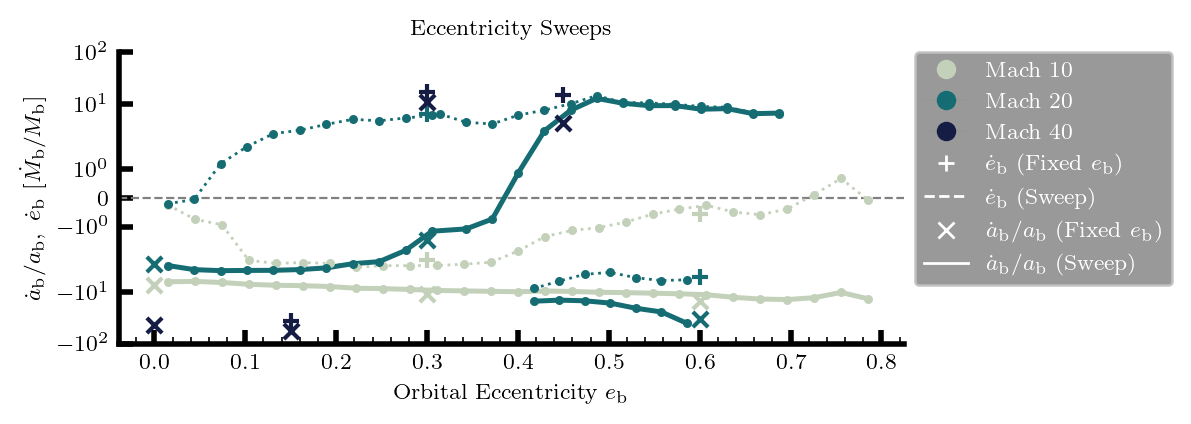

In [5]:
fig, ax  = plt.subplots(figsize=[1.2 * text_width, 0.9 * column_width], dpi=200)
savename = 'Sweep'


cmap1   = cmocean.cm.tempo_r
colors1 = [cmap1(i / 2.5) for i in range(0,3)]

_adot_dark  = cmap1(0 / 3.0)
_adot_medi  = cmap1(1 / 3.0)
_adot_light = cmap1(2 / 2.4)

_edot_dark  = cmap1(0 / 3.0)
_edot_medi  = cmap1(1 / 3.0)
_edot_light = cmap1(2 / 2.4)


Mach10_ea , Mach10_ma , _ = ComputeBinnedStats(Mach10_e , Mach10_adot , 0.03)
Mach10_ee , Mach10_me , _ = ComputeBinnedStats(Mach10_e , Mach10_edot , 0.03)
Mach20_eaa, Mach20_maa, _ = ComputeBinnedStats(Mach20_ea, Mach20_adota, 0.03)
Mach20_eea, Mach20_mea, _ = ComputeBinnedStats(Mach20_ea, Mach20_edota, 0.03)
Mach20_eab, Mach20_mab, _ = ComputeBinnedStats(Mach20_eb, Mach20_adotb, 0.03)
Mach20_eeb, Mach20_meb, _ = ComputeBinnedStats(Mach20_eb, Mach20_edotb, 0.03)
Mach20_eac, Mach20_mac, _ = ComputeBinnedStats(Mach20_ec, Mach20_adotc, 0.03)
Mach20_eec, Mach20_mec, _ = ComputeBinnedStats(Mach20_ec, Mach20_edotc, 0.03)

ax.plot(Mach10_ea      , Mach10_ma     , linewidth=1.8, linestyle='solid' , color=_adot_light, zorder=3)
ax.plot(Mach10_ee      , Mach10_me     , linewidth=1.0, linestyle='dotted', color=_edot_light, zorder=3)
ax.plot(Mach20_eaa     , Mach20_maa    , linewidth=1.8, linestyle='solid' , color=_adot_medi , zorder=3)
ax.plot(Mach20_eab[1:] , Mach20_mab[1:], linewidth=1.8, linestyle='solid' , color=_adot_medi , zorder=3)
ax.plot(Mach20_eea     , Mach20_mea    , linewidth=1.0, linestyle='dotted', color=_edot_medi , zorder=3)
ax.plot(Mach20_eeb     , Mach20_meb    , linewidth=1.0, linestyle='dotted', color=_edot_medi , zorder=3)
ax.plot(Mach20_eac     , Mach20_mac    , linewidth=1.8, linestyle='solid' , color=_adot_medi , zorder=3)
ax.plot(Mach20_eec     , Mach20_mec    , linewidth=1.0, linestyle='dotted', color=_edot_medi , zorder=3)

ax.plot([Mach20_eaa[-1], Mach20_eab[1]], [Mach20_maa[-1], Mach20_mab[1]], linewidth=1.8, linestyle='solid' , color=_adot_medi , zorder=3)

ax.scatter(Mach10_ea     , Mach10_ma     , color=_adot_light, marker='o', s=5, zorder=3)
ax.scatter(Mach10_ee     , Mach10_me     , color=_edot_light, marker='o', s=5, zorder=3)
ax.scatter(Mach20_eaa    , Mach20_maa    , color=_adot_medi , marker='o', s=5, zorder=3)
ax.scatter(Mach20_eea    , Mach20_mea    , color=_edot_medi , marker='o', s=5, zorder=3)
ax.scatter(Mach20_eeb    , Mach20_meb    , color=_edot_medi , marker='o', s=5, zorder=3)
ax.scatter(Mach20_eab[1:], Mach20_mab[1:], color=_adot_medi , marker='o', s=5, zorder=3)
ax.scatter(Mach20_eec    , Mach20_mec    , color=_edot_medi , marker='o', s=5, zorder=3)
ax.scatter(Mach20_eac    , Mach20_mac    , color=_adot_medi , marker='o', s=5, zorder=3)

# Mach 10 scatter points
ax.scatter(0.0, -7.39, color=_adot_light, marker='x', s=30, zorder=4)
ax.scatter(0.3,-10.79, color=_adot_light, marker='x', s=30, zorder=4)
ax.scatter(0.3, -2.41, color=_edot_light, marker='+', s=30, zorder=4)
ax.scatter(0.6,-14.77, color=_adot_light, marker='x', s=30, zorder=4)
ax.scatter(0.6, -0.55, color=_edot_light, marker='+', s=30, zorder=4)

# Mach 20 scatter points
ax.scatter(0.0, -2.89, color=_adot_medi, marker='x', s=30, zorder=4)
ax.scatter(0.3, -1.45, color=_adot_medi, marker='x', s=30, zorder=4)
ax.scatter(0.3,  6.39, color=_edot_medi, marker='+', s=30, zorder=4)
ax.scatter(0.6,-32.90, color=_adot_medi, marker='x', s=30, zorder=4)
ax.scatter(0.6, -5.10, color=_edot_medi, marker='+', s=30, zorder=4)

# Mach 40 scatter points
ax.scatter(0.0, -44.34, color=_adot_dark, marker='x', s=30, zorder=4)#, label=r'Mach 40, $\dot{a}/a$')
ax.scatter(0.15,-55.78, color=_adot_dark, marker='x', s=30, zorder=4)#, label=r'Mach 40, $\dot{e}$')
ax.scatter(0.15,-35.96, color=_edot_dark, marker='+', s=30, zorder=4)
ax.scatter(0.30, 11.11, color=_adot_dark, marker='x', s=30, zorder=4)
ax.scatter(0.30, 17.19, color=_edot_dark, marker='+', s=30, zorder=4)
ax.scatter(0.45,  4.34, color=_adot_dark, marker='x', s=30, zorder=4)
ax.scatter(0.45, 14.76, color=_edot_dark, marker='+', s=30, zorder=4)



ax.autoscale()
_ylo, _yhi = ax.get_ylim()

ax.set_ylim(_ylo, _yhi)   
ax.axhline(y=0, color='0.5', linewidth=0.8, linestyle='--', zorder=2)

ax.set_xlabel('Orbital Eccentricity $e_\mathrm{b}$')
ax.set_ylabel(r'$\dot{a}_\mathrm{b}/a_\mathrm{b},\ \dot{e}_\mathrm{b}\ [\dot{M}_\mathrm{b}/M_\mathrm{b}]$')
ax.set_title(r'Eccentricity Sweeps', fontsize=8)
#ax.legend(loc='upper right', frameon=True, framealpha=0.9, edgecolor='none')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0,frameon=True, framealpha=0.9, edgecolor='none')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(which='both', top=False, right=False)
ax.minorticks_on()
ax.tick_params(which='minor', length=2.5, direction='in')
fig.tight_layout()

ax.set_yscale('symlog')
ax.set_ylim([-100, 100])

legend_elements = [
    Line2D([0], [0], marker='o', color=_adot_light, linewidth=0.01, label = r'Mach 10'),
    Line2D([0], [0], marker='o', color=_adot_medi , linewidth=0.01, label = r'Mach 20'),
    Line2D([0], [0], marker='o', color=_adot_dark , linewidth=0.01, label = r'Mach 40'),
    Line2D([0], [0], marker='+', color='white'    , linewidth=0.01, label = r'$\dot{e}_\mathrm{b}$ (Fixed $e_\mathrm{b}$)'),
    Line2D([0], [0], linestyle='dashed', color='white'    , linewidth=1.00, label = r'$\dot{e}_\mathrm{b}$ (Sweep)'),
    Line2D([0], [0], marker='x', color='white'    , linewidth=0.01, label = r'$\dot{a}_\mathrm{b}/a_\mathrm{b}$ (Fixed $e_\mathrm{b}$)'),
    Line2D([0], [0], linestyle='solid' , color='white'    , linewidth=1.00, label = r'$\dot{a}_\mathrm{b}/a_\mathrm{b}$ (Sweep)'),
]


ax.legend(
    handles=legend_elements,
    loc='center left',
    bbox_to_anchor=(1.0, 0.6),
    fontsize=8,
    frameon=True,
    facecolor='gray',
    edgecolor='silver',
    labelcolor='white',
)


plt.tight_layout()
plt.savefig('Sweep', dpi=600)

/tmp/ipykernel_2422730/2237234448.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0,frameon=True, framealpha=0.9, edgecolor='none')


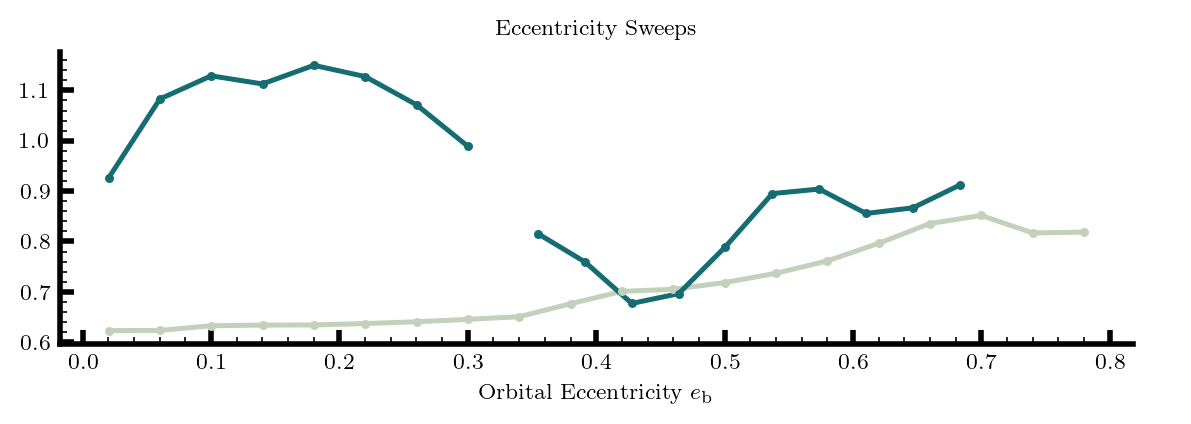

In [ ]:
fig, ax  = plt.subplots(figsize=[1.2 * text_width, 0.9 * column_width], dpi=200)
savename = 'Mdot'

cmap1   = cmocean.cm.tempo_r
colors1 = [cmap1(i / 2.5) for i in range(0,3)]

_dark  = cmap1(0 / 3.0)
_medi  = cmap1(1 / 3.0)
_light = cmap1(2 / 2.4)


Mach10_ea , Mach10_mM , _ = ComputeBinnedStats(Mach10_e , Mach10_Mdot , 0.04)
Mach20_eaa, Mach20_mMa, _ = ComputeBinnedStats(Mach20_ea, Mach20_Mdota, 0.04)
Mach20_eab, Mach20_mMb, _ = ComputeBinnedStats(Mach20_eb, Mach20_Mdotb, 0.04)


ax.plot(Mach10_ea      , Mach10_mM     , linewidth=1.8, linestyle='solid', color=_light, zorder=3)#, label=r'Mach 10, $\dot{a}/a$')
ax.plot(Mach20_eaa     , Mach20_mMa    , linewidth=1.8, linestyle='solid', color=_medi , zorder=3)#, label=r'Mach 20, $\dot{a}/a$')
ax.plot(Mach20_eab[1:] , Mach20_mMb[1:], linewidth=1.8, linestyle='solid', color=_medi , zorder=3)

ax.scatter(Mach10_ea     , Mach10_mM     , color=_light, marker='o', s=5, zorder=3)
ax.scatter(Mach20_eaa    , Mach20_mMa    , color=_medi , marker='o', s=5, zorder=3)
ax.scatter(Mach20_eab[1:], Mach20_mMb[1:], color=_medi , marker='o', s=5, zorder=3)


ax.autoscale()
_ylo, _yhi = ax.get_ylim()

ax.set_ylim(_ylo, _yhi)   
ax.axhline(y=0, color='0.5', linewidth=0.8, linestyle='--', zorder=2)

ax.set_xlabel('Orbital Eccentricity $e_\mathrm{b}$')
#ax.set_ylabel(r'$\dot{a}_\mathrm{b}/a_\mathrm{b},\ \dot{e}_\mathrm{b}\ [\dot{M}_\mathrm{b}/M_\mathrm{b}]$')
ax.set_title(r'Eccentricity Sweeps', fontsize=8)
#ax.legend(loc='upper right', frameon=True, framealpha=0.9, edgecolor='none')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0,frameon=True, framealpha=0.9, edgecolor='none')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(which='both', top=False, right=False)
ax.minorticks_on()
ax.tick_params(which='minor', length=2.5, direction='in')
fig.tight_layout()



plt.tight_layout()
plt.savefig('MdotSweep', dpi=600)

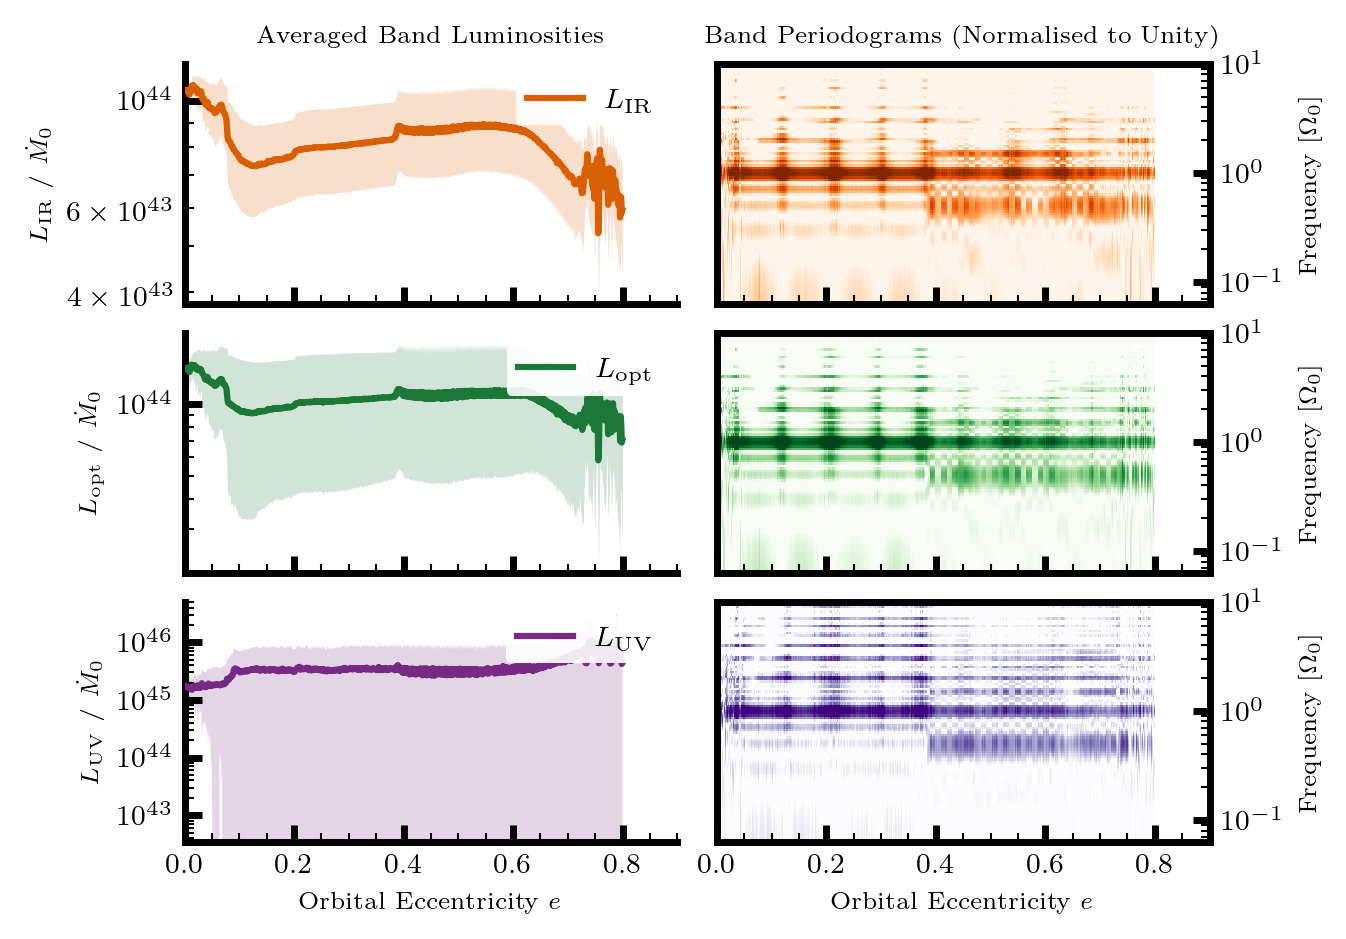

In [12]:
Mach20 = False

if Mach20:
    infared, optical, uv, e, t = Mach20_infared, Mach20_optical, Mach20_uv, Mach20_e, Mach20_t
else:
    infared, optical, uv, e, t = Mach10_infared, Mach10_optical, Mach10_uv, Mach10_e, Mach10_t

delta_e = 0.001
e_f     = e[-1]

# --- EM panels: L(e) line (left) + 2D LS spectrogram P(e, f) (right) ---
_bands = [
    (infared,  r'$L_\mathrm{IR}$',  r'$L_\mathrm{IR}\ /\ \dot{M}_0$',  '#D95F02', 'Oranges'),
    (optical,  r'$L_\mathrm{opt}$', r'$L_\mathrm{opt}\ /\ \dot{M}_0$', '#1B7837', 'Greens' ),
    (uv     ,  r'$L_\mathrm{UV}$',  r'$L_\mathrm{UV}\ /\ \dot{M}_0$',  '#762A83', 'Purples'),
]

# eccentricity bins for the 2D spectrogram 
_n_e      = int(e_f / delta_e)
_e_edges  = np.linspace(0.0, e_f, _n_e + 1)
_e_ctrs   = 0.5 * (_e_edges[:-1] + _e_edges[1:])
_freq_2d  = np.logspace(-1.2, 1, 100)           # cycles / orbit, 0.1 – 10
_omega_2d = 2.0 * np.pi * _freq_2d
_min_samp = 5                                    # min points per bin for reliable LS

# pre-compute L(e) stats and per-bin periodograms for each band
_band_stats = []
for lum, band_label, ylabel, color, cmap in _bands:
    ec, lm, ls = ComputeBinnedStats(e, lum, delta_e)
    power_2d   = np.full((_n_e, len(_freq_2d)), np.nan)

    for j in range(_n_e):
        mask = (e >= _e_edges[j]) & (e < _e_edges[j + 1])
        if mask.sum() >= _min_samp:
            t_bin   = t[mask]
            sig_bin = lum[mask] - np.mean(lum[mask])
            var_bin = np.var(sig_bin)
            if var_bin > 0:
                p          = lombscargle(t_bin, sig_bin, _omega_2d)
                p         /= var_bin          # Scargle-normalised LS power
                med        = np.median(p)
                if med > 0:
                    p /= med                  # excess above noise floor; stable w.r.t. freq resolution
                power_2d[j] = p

    _band_stats.append((ec, lm, ls, power_2d, band_label, ylabel, color, cmap))

fig2 = plt.figure(figsize=[text_width, text_width * 0.75], dpi = 250)
gs   = fig2.add_gridspec(3, 2, width_ratios=[1.0, 1.0],
                            hspace=0.12, wspace=0.08,
                            left=0.10, right=0.92, top=0.93, bottom=0.10)

ax_lum_ref = None
ax_per_ref = None
last_im    = None

for i, (ec, lm, ls, power_2d, band_label, ylabel, color, cmap) in enumerate(_band_stats):

    ax_lum = fig2.add_subplot(gs[i, 0], sharex=ax_lum_ref)
    ax_per = fig2.add_subplot(gs[i, 1], sharex=ax_per_ref)
    if ax_lum_ref is None:
        ax_lum_ref = ax_lum
    if ax_per_ref is None:
        ax_per_ref = ax_per

    # left: mean luminosity ± 1σ vs eccentricity
    ax_lum.fill_between(ec, lm - ls, lm + ls,
                            color=color, alpha=0.2, linewidth=0, zorder=1)
    ax_lum.plot(ec, lm, linewidth=1.8, color=color, label=band_label, zorder=3)
    ax_lum.set_yscale('log')
    ax_lum.set_ylabel(ylabel, fontsize=7)
    ax_lum.set_xlim(0.0, 0.9)
    ax_lum.legend(loc='upper right', frameon=True, framealpha=0.9, edgecolor='none')
    ax_lum.spines['top'].set_visible(False)
    ax_lum.spines['right'].set_visible(False)
    ax_lum.tick_params(which='both', top=False, right=False)
    ax_lum.minorticks_on()
    ax_lum.tick_params(which='minor', length=2.5, direction='in')
    
    if i < 2:
        ax_lum.tick_params(labelbottom=False)

    from matplotlib.colors import LogNorm
    valid   = power_2d[np.isfinite(power_2d) & (power_2d > 0)]
    vmin    = 1.0    # or just fix at 1.0 since you median-normalised
    vmax    = np.percentile(valid, 99)   # captures the bulk without being blown out by spikes
    norm    = LogNorm(vmin=vmin, vmax=vmax)
    im      = ax_per.pcolormesh(_e_ctrs, _freq_2d, power_2d.T, cmap=cmap, shading='auto', rasterized=True, norm=norm)
    last_im = im
    ax_per.set_yscale('log')
    ax_per.set_ylim(_freq_2d[0], _freq_2d[-1])
    ax_per.set_xlim(0.0, 0.9)
    ax_per.set_ylabel(r'Frequency $[\Omega_0]$', fontsize=7)
    ax_per.yaxis.set_label_position('right')
    ax_per.yaxis.tick_right()
    ax_per.tick_params(which='both', top=False, left=False)
    ax_per.minorticks_on()
    ax_per.tick_params(which='minor', length=2.5, direction='in')

    if i == 0:
        ax_lum.set_title('Averaged Band Luminosities', fontsize=7)
        ax_per.set_title('Band Periodograms (Normalised to Unity)', fontsize=7)

    if i == 2:
        ax_lum.set_xlabel(r'Orbital Eccentricity $e$', fontsize=7)
        ax_per.set_xlabel(r'Orbital Eccentricity $e$', fontsize=7)
    else:
        ax_lum.tick_params(labelbottom=False)
        ax_per.tick_params(labelbottom=False)


plt.savefig('Mach20_Emission.png', bbox_inches='tight')


# Circumbinary Disk Profiles

### Time and Azimuthally Average 

In [7]:
def _process_branch(LoadingDirectory, Nbins=500):
    checkpoint_files = sorted(glob.glob(LoadingDirectory + 'chkpt.*.pk'))
    Sigma, Vx, Vy, Pressure, mesh, SS73, gamma, r_mid, FJ_r, Sigma_co, Pressure_co, \
          Vx_co, Vy_co, Div_v, r_bins, dT_dlnr, dP_dlnr = TimeAverage(checkpoint_files, Nbins)
    print('Time Averaged        ' + LoadingDirectory)
    DiskStats = AzimuthallyAverageCBD(Sigma, Vx, Vy, Pressure, mesh, SS73, gamma, r_bins)
    DiskStats.update({'Sigma_co': Sigma_co, 'Pressure_co': Pressure_co,
                      'Vx_co': Vx_co, 'Vy_co': Vy_co, 'Div_v': Div_v,
                      'FJ_Rey': FJ_r, 'FJ_Rad': r_mid, 'Radius': r_bins, 'dT_dlnr': dT_dlnr, 'dP_dlnr': dP_dlnr})
    print('Azimuthally Averaged ' + LoadingDirectory)
    return DiskStats

def ProcessTimeAzimuthalAverages(loading_dirs, save=True, Nbins=500, n_workers=None, savename='disk_profiles.pkl'):
    if isinstance(loading_dirs, str):
        loading_dirs = [loading_dirs]

    worker_count = n_workers or len(loading_dirs)
    with ProcessPoolExecutor(max_workers=worker_count) as pool:
        result = list(pool.map(partial(_process_branch, Nbins=Nbins), loading_dirs))

    if save:
        with open(savename, 'wb') as f:
            pickle.dump(result, f)
    return result


def TimeAverage(checkpoint_files, Nbins):
    sigma_sum = press_sum = vx_sum = vy_sum = None
    sigma_co = vx_co = vy_co = press_co = div_v_co = None
    Fj_r = None
    mesh = r_bins = None

    for f in checkpoint_files:
        chkpt = load_checkpoint(f)
        sigma = chkpt["solution"][:, :, 0].T
        vx    = chkpt['solution'][:, :, 1].T
        vy    = chkpt['solution'][:, :, 2].T
        press = chkpt["solution"][:, :, 3].T
        if sigma_sum is None:
            mesh   = chkpt["mesh"]
            r_bins = np.linspace(0., mesh.x1, Nbins)
            sigma_sum, press_sum, vx_sum, vy_sum = sigma, press, vx, vy
            _, fj_r = compute_FJ_profile(sigma, vx, vy, mesh, r_bins)
            Fj_r    = fj_r
            corot   = make_corotating_maps(sigma, vx, vy, press, mesh, chkpt['point_masses'])
            dT_dlnr_sum = compute_torque_profile(sigma, mesh, chkpt['point_masses'], r_bins)
            dP_dlnr_sum = compute_power_profile(sigma, mesh, chkpt['point_masses'], r_bins)
            sigma_co, vx_co, vy_co, press_co, div_v_co = corot[2], corot[3], corot[4], corot[5], corot[6]
        else:
            sigma_sum += sigma; press_sum += press; vx_sum += vx; vy_sum += vy
            _, fj_r  = compute_FJ_profile(sigma, vx, vy, mesh, r_bins)
            Fj_r    += fj_r
            corot    = make_corotating_maps(sigma, vx, vy, press, mesh, chkpt['point_masses'])
            dT_dlnr_sum += compute_torque_profile(sigma, mesh, chkpt['point_masses'], r_bins)
            dP_dlnr_sum += compute_power_profile(sigma, mesh, chkpt['point_masses'], r_bins)  # accumulate
            sigma_co += corot[2]; vx_co += corot[3]; vy_co += corot[4]
            press_co += corot[5]; div_v_co += corot[6]

    n     = len(checkpoint_files)
    r_mid = 0.5 * (r_bins[:-1] + r_bins[1:])
    return (sigma_sum/n, vx_sum/n, vy_sum/n, press_sum/n,
            chkpt["mesh"], chkpt["SS73"], chkpt['model_parameters']['gamma_law_index'],
            r_mid, Fj_r/n, sigma_co/n, press_co/n, vx_co/n, vy_co/n, div_v_co/n, r_bins, dT_dlnr_sum/n, dP_dlnr_sum/n) 

def make_corotating_maps(sigma, vx, vy, press, mesh, pointmasses):
    ni, nj = mesh.shape
    x      = np.array([mesh.cell_coordinates(i, 0)[0] for i in range(ni)])
    y      = np.array([mesh.cell_coordinates(0, j)[1] for j in range(nj)])
    X, Y   = np.meshgrid(x, y)
    R      = np.sqrt(X**2 + Y**2)
    r_max  = x[-1]

    primary, secondary = pointmasses 
    phi = np.arctan2(primary.position_y, primary.position_x)

    # Step 1: subtract frame angular velocity  v_corot = v_inertial - omega x r 
    Omega_b = (primary.position_x * primary.velocity_y - primary.position_y * primary.velocity_x)/(primary.position_y**2 + primary.position_x**2)
    vx_f   = vx + Omega_b * Y
    vy_f   = vy - Omega_b * X

    # Step 2: project onto co-rotating axes
    c, s     = np.cos(phi), np.sin(phi)
    vx_corot =  c * vx_f + s * vy_f
    vy_corot = -s * vx_f + c * vy_f

    # Step 3: rotate fields spatially so binary sits on +x axis
    angle_deg = np.degrees(phi)

    def _rot(field):
        return nd_rotate(field, angle_deg, reshape=False, mode='constant', cval=0.0)

    sigma_rot = _rot(sigma)
    vx_rot    = _rot(vx_corot)
    vy_rot    = _rot(vy_corot)
    press_rot = _rot(press)

    # Step 4: mask corners beyond r_max
    mask = R > r_max
    for arr in (sigma_rot, vx_rot, vy_rot, press_rot):
        arr[mask] = np.nan

    dx    = x[1] - x[0]
    dy    = y[1] - y[0]
    div_v = np.gradient(vx_rot, dx, axis=1) + np.gradient(vy_rot, dy, axis=0)
    return (x, y, sigma_rot, vx_rot, vy_rot, press_rot, div_v)

def compute_torque_profile(sigma, mesh, point_masses, r_bins):
    ni, nj = mesh.shape
    x = np.array([mesh.cell_coordinates(i, 0)[0] for i in range(ni)])
    y = np.array([mesh.cell_coordinates(0, j)[1] for j in range(nj)])
    X, Y = np.meshgrid(x, y)
    R    = np.sqrt(X**2 + Y**2)

    primary, secondary = point_masses
    rs1 = primary.softening_length
    rs2 = secondary.softening_length
    R_1 = np.sqrt((X - primary.position_x)**2   + (Y - primary.position_y)**2)
    R_2 = np.sqrt((X - secondary.position_x)**2 + (Y - secondary.position_y)**2)

    dA  = mesh.dx * mesh.dy
    fx1 = -sigma * primary.mass   * (X - primary.position_x)   / (R_1**2 + rs1**2)**1.5
    fy1 = -sigma * primary.mass   * (Y - primary.position_y)   / (R_1**2 + rs1**2)**1.5
    fx2 = -sigma * secondary.mass * (X - secondary.position_x) / (R_2**2 + rs2**2)**1.5
    fy2 = -sigma * secondary.mass * (Y - secondary.position_y) / (R_2**2 + rs2**2)**1.5
    t   = (X * (fy1 + fy2) - Y * (fx1 + fx2)) * dA

    r_centers  = 0.5 * (r_bins[:-1] + r_bins[1:])
    n_out      = len(r_centers)
    idx        = np.digitize(R.ravel(), r_bins) - 1
    valid      = (idx >= 0) & (idx < n_out)
    t_sum      = np.bincount(idx[valid], weights=t.ravel()[valid], minlength=n_out).astype(float)
    cnt        = np.bincount(idx[valid], minlength=n_out)
    dT_dlnr    = t_sum * r_centers
    dT_dlnr[cnt == 0] = np.nan
    return dT_dlnr

def compute_power_profile(sigma, mesh, point_masses, r_bins):
    ni, nj = mesh.shape
    x = np.array([mesh.cell_coordinates(i, 0)[0] for i in range(ni)])
    y = np.array([mesh.cell_coordinates(0, j)[1] for j in range(nj)])
    X, Y = np.meshgrid(x, y)
    R    = np.sqrt(X**2 + Y**2)

    primary, secondary = point_masses
    rs1 = primary.softening_length
    rs2 = secondary.softening_length
    R_1 = np.sqrt((X - primary.position_x)**2   + (Y - primary.position_y)**2)
    R_2 = np.sqrt((X - secondary.position_x)**2 + (Y - secondary.position_y)**2)

    dA  = mesh.dx * mesh.dy
    fx1 = -sigma * primary.mass   * (X - primary.position_x)   / (R_1**2 + rs1**2)**1.5
    fy1 = -sigma * primary.mass   * (Y - primary.position_y)   / (R_1**2 + rs1**2)**1.5
    fx2 = -sigma * secondary.mass * (X - secondary.position_x) / (R_2**2 + rs2**2)**1.5
    fy2 = -sigma * secondary.mass * (Y - secondary.position_y) / (R_2**2 + rs2**2)**1.5

    # F_gas→star = -F_star→gas, so P = v · (-f) for each component
    vx1, vy1 = primary.velocity_x,   primary.velocity_y
    vx2, vy2 = secondary.velocity_x, secondary.velocity_y
    p = -(vx1 * fx1 + vy1 * fy1 + vx2 * fx2 + vy2 * fy2) * dA

    r_centers = 0.5 * (r_bins[:-1] + r_bins[1:])
    n_out     = len(r_centers)
    idx       = np.digitize(R.ravel(), r_bins) - 1
    valid     = (idx >= 0) & (idx < n_out)
    p_sum     = np.bincount(idx[valid], weights=p.ravel()[valid], minlength=n_out).astype(float)
    cnt       = np.bincount(idx[valid], minlength=n_out)
    dP_dlnr   = p_sum * r_centers
    dP_dlnr[cnt == 0] = np.nan
    return dP_dlnr


def compute_FJ_profile(Sigma, Vx, Vy, mesh, r_bins):
    x = np.array([mesh.cell_coordinates(i, 0)[0] for i in range(mesh.shape[0])])
    y = np.array([mesh.cell_coordinates(0, j)[1] for j in range(mesh.shape[1])])
    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)

    Vr   = (X * Vx + Y * Vy) / np.where(R == 0, np.nan, R)
    Vphi = (-Y * Vx + X * Vy) / np.where(R == 0, np.nan, R)

    r_mid = 0.5 * (r_bins[:-1] + r_bins[1:])
    flat  = slice(None)  # keep flat views

    idx   = np.digitize(R.ravel(), r_bins) - 1
    valid = (idx >= 0) & (idx < len(r_mid)) & ~np.isnan(R.ravel())
    idx, S, vr, vp = idx[valid], Sigma.ravel()[valid], Vr.ravel()[valid], Vphi.ravel()[valid]

    nb = len(r_mid)
    cnt   = np.bincount(idx, minlength=nb).astype(float)
    wS    = np.bincount(idx, weights=S,    minlength=nb)
    wSvr  = np.bincount(idx, weights=S*vr, minlength=nb)
    wSvp  = np.bincount(idx, weights=S*vp, minlength=nb)

    good      = cnt >= 8
    mean_vr   = np.where(good, wSvr / np.where(wS > 0, wS, np.nan), np.nan)
    mean_vp   = np.where(good, wSvp / np.where(wS > 0, wS, np.nan), np.nan)

    dvr = vr - mean_vr[idx]
    dvp = vp - mean_vp[idx]

    wFlux = np.bincount(idx, weights=S * dvr * dvp, minlength=nb)
    FJ_r  = np.where(good, 2 * np.pi * r_mid**2 * wFlux / cnt, np.nan)

    return r_mid, FJ_r

def AzimuthallyAverageCBD(Sigma, Vx, Vy, Pressure, mesh, SS73, gamma, r_bins):
    Mdrop   = SS73.Mdrop
    cs      = (gamma * Pressure / Sigma)**0.5
    ni, nj  = mesh.shape
    x = np.array([mesh.cell_coordinates(i, 0)[0] for i in range(ni)])
    y = np.array([mesh.cell_coordinates(0, j)[1] for j in range(nj)])
    X, Y    = np.meshgrid(x, y, indexing="xy")
    Sigma   = Sigma   * SS73.surface_density_coefficient
    Pressure= Pressure* SS73.surface_pressure_coefficient
    R       = np.sqrt(X**2 + Y**2)
    speed   = np.sqrt(Vx**2 + Vy**2)
    vr      = (Vx*X + Vy*Y) / R
    ang_mom = X*Vy - Y*Vx
    v_dot_v = speed**2;  v_dot_r = Vx*X + Vy*Y
    ex      = v_dot_v*X - v_dot_r*Vx - X/R
    ey      = v_dot_v*Y - v_dot_r*Vy - Y/R
    e       = np.sqrt(ex**2 + ey**2)
    mach    = speed / cs

    r_flat = R.ravel()
    arrays = {
        'V': speed.ravel(), 
        'E': e.ravel(),
        'D': (Sigma * Mdrop**(3/5)).ravel(),
        'M': mach.ravel(),   
        'Vr': vr.ravel(),
        'l': ang_mom.ravel(),
        'P': (Pressure * Mdrop).ravel(),
    }

    DiskStats = {}
    for name, arr in arrays.items():
        for stat, prefix in [('median', 'Median'), ('min', 'Min'), ('max', 'Max')]:
            vals, _, _ = binned_statistic(r_flat, arr, statistic=stat, bins=r_bins)
            DiskStats[f'{prefix}{name}'] = list(vals)

    return DiskStats

In [8]:
# time averaged subdirectories,
Host   = '/mnt/beegfs/haimagrp/david_oneill/sailfish/Retrograde/Fixed_e/'
Branch = ['e00Mach10/TimeAverages/', 'e03Mach10/TimeAverages/', 'e06Mach10/TimeAverages/',
          'e00Mach20/TimeAverages/', 'e03Mach20/TimeAverages/', 'e06Mach20/TimeAverages/',
          'e00Mach40/TimeAverages/', 'e03Mach40/TimeAverages/', 'e06Mach40/TimeAverages/']

if False:
    Averaged_Disk_Profiles = ProcessTimeAzimuthalAverages(
        loading_dirs = [Host + b for b in Branch],
        save=True, 
        Nbins=500, 
        n_workers=len(Branch), 
        savename='disk_profiles.pkl'
    )
else:
    with open('disk_profiles.pkl', 'rb') as f:
        Averaged_Disk_Profiles = pickle.load(f)

In [9]:
def TorqueFraction(ell0, r):
    f = 1.0 - ell0 / np.sqrt(r)
    if f < 1e-2:
        return np.nan
    else:
        return f
    
def ComputeMeanFromMap(field, x, y, r_bins):
    X, Y  = np.meshgrid(x, y)
    R     = np.sqrt(X**2 + Y**2)
    r_mid = 0.5 * (r_bins[:-1] + r_bins[1:])

    f_flat = field.ravel()
    r_flat = R.ravel()
    valid  = ~np.isnan(f_flat)

    idx  = np.digitize(r_flat[valid], r_bins) - 1
    mask = (idx >= 0) & (idx < len(r_mid))
    idx  = idx[mask]
    f    = f_flat[valid][mask]

    nb   = len(r_mid)
    cnt  = np.bincount(idx, minlength=nb).astype(float)
    wF   = np.bincount(idx, weights=f, minlength=nb)

    return r_mid, np.where(cnt >= 8, wF / np.where(cnt > 0, cnt, np.nan), np.nan)



/tmp/ipykernel_974573/2694292233.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(frameon=False, loc='lower left')


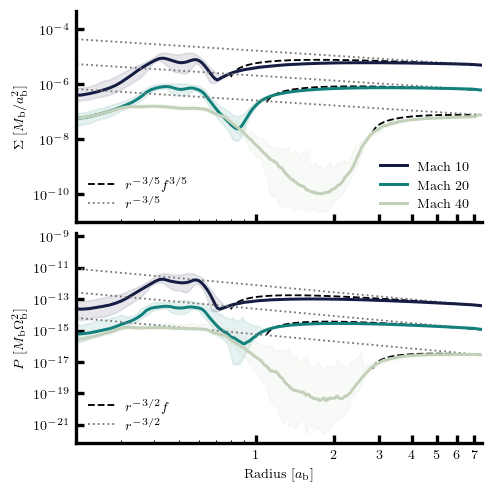

In [17]:
# Calibration
cmap   = cmocean.cm.tempo_r
colors = [cmap(i / 2.4) for i in range(0,3)]
_lw    = 1.8   # main data lines
_lw_r  = 1.1   # reference/theory lines
_fa    = 0.10  # fill_between alpha
_c_ref = '#777777'
_hot   = plt.cm.hot

fig  = plt.figure(figsize=(0.8*text_width, 0.8 * text_width), dpi=120)
gs   = fig.add_gridspec(2, 1, hspace=0.0)
axes = [fig.add_subplot(gs[i]) for i in range(2)]
ax1, ax2 = axes
fig.set_layout_engine('constrained')

Radius  = Averaged_Disk_Profiles[0]['Radius'][1:]
_xticks = [1, 2, 3, 4, 5, 6, 7]
for ax in axes:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(0.2, Radius[-1])
    ax.set_xticks(_xticks)
    ax.set_xticklabels([str(v) for v in _xticks])
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(which='both', direction='in', top=False, right=False)
    ax.tick_params(labelbottom=False)

ax2.tick_params(labelbottom=True)
ax2.set_xlabel(r'Radius $[a_\mathrm{b}]$')

#for ax, lbl in zip(axes, 'ab'):
#    ax.text(0.03, 0.93, f'$({lbl})$', transform=ax.transAxes, fontsize=8, fontweight='bold', va='top', ha='left', zorder=4)

ell0 = [0.88, 1.03, 1.66]
for index in range(3):
    DiskStats = Averaged_Disk_Profiles[3 * index]

    f0  = np.array([TorqueFraction(ell0[index],r) for r in Radius])

    # ── (a) Surface density ───────────────────────────────────────────────────────
    Sigma_l0 = Radius**(-3/5) * f0**0.6
    Sigma_SS = Radius**(-3/5)

    ax1.plot(Radius, DiskStats['MedianD'][-1] * Sigma_l0 / Sigma_l0[-1], color='k',    lw=_lw_r, ls='--')
    ax1.plot(Radius, DiskStats['MedianD'][-1] * Sigma_SS / Sigma_SS[-1], color=_c_ref, lw=_lw_r, ls=':')
    ax1.fill_between(Radius, DiskStats['MinD'], DiskStats['MaxD'], color=colors[index], alpha=_fa)
    ax1.plot(Radius, DiskStats['MedianD'], color=colors[index], lw=_lw, ls='solid')
    ax1.legend(frameon=False, loc='lower left')

    # ── (b) Pressure ───────────────────────────────────────────────────────
    Pressure_l0 = Radius**(-3/2) * f0
    Pressure_SS = Radius**(-3/2)
    ax2.plot(Radius, DiskStats['MedianP'][-1] * Pressure_l0 / Pressure_l0[-1], color='k',    lw=_lw_r, ls='--')
    ax2.plot(Radius, DiskStats['MedianP'][-1] * Pressure_SS / Pressure_SS[-1], color=_c_ref, lw=_lw_r, ls=':')
    ax2.fill_between(Radius, DiskStats['MinP'], DiskStats['MaxP'], color=colors[index], alpha=_fa)
    ax2.plot(Radius, DiskStats['MedianP'], color=colors[index], lw=_lw, ls='solid')
    

ax1.set_ylabel(r'$\Sigma\;[M_\mathrm{b}/a_\mathrm{b}^2]$')
ax2.set_ylabel(r'$P\;[M_\mathrm{b}\Omega_\mathrm{b}^2]$')



# ax1: one entry per Mach number (filled band + solid line, shown as a solid colored line)
ax1_handles_a = [
    Line2D([0], [0], color=colors[i], lw=_lw, ls='solid', label=lbl)
    for i, lbl in enumerate(['Mach 10', 'Mach 20', 'Mach 40'])
]
leg_a = ax1.legend(handles=ax1_handles_a, frameon=False, loc='lower right')

ax1_handles_b = [
    Line2D([0], [0], color='k',    lw=_lw_r, ls='--', label=r'$r^{-3/5}f^{3/5}$'),
    Line2D([0], [0], color=_c_ref, lw=_lw_r, ls=':',  label=r'$r^{-3/5}$'),
]
ax1.add_artist(leg_a)  # preserve first legend before it gets replaced
ax1.legend(handles=ax1_handles_b, frameon=False, loc='lower left')

# ax2: the two reference curves
ax2_handles = [
    Line2D([0], [0], color='k',    lw=_lw_r, ls='--', label=r'$r^{-3/2}f$'),
    Line2D([0], [0], color=_c_ref, lw=_lw_r, ls=':',  label=r'$r^{-3/2}$'),
]
ax2.legend(handles=ax2_handles, frameon=False, loc='lower left')


#ax1.legend(frameon=False, loc='lower left')
#ax2.legend(frameon=False, loc='lower left')

plt.savefig('DiskAveragedProfile.png', dpi=300, bbox_inches='tight')

In [14]:
# Eccentricity
# Mach number
# Angular momentum fluxes

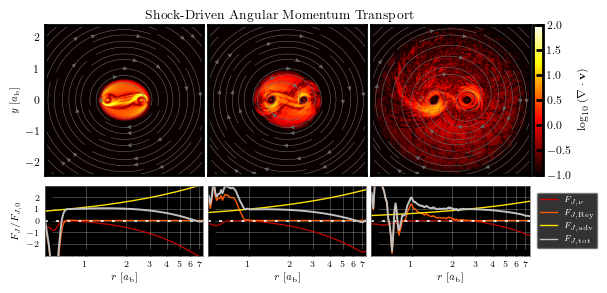

In [16]:
fig = plt.figure(figsize=(1.25* text_width, 0.6 * text_width), dpi=100)
gs  = gridspec.GridSpec(
    2, 3,
    height_ratios=[3, 1.4],
    hspace=0.1,
    wspace=0.03,
)

map_axes  = [fig.add_subplot(gs[0, i]) for i in range(3)]  # top row
prof_axes = [fig.add_subplot(gs[1, i]) for i in range(3)]  # bottom row

Mdrop = [6.454004361716007e-08, 2.065281395749122e-06, 6.608900466397191e-05]
Mdot0 = [0.0054329053152425390, 0.0001697782911013293, 5.305571596916542e-06]
ell0  = [0.88, 1.03, 1.66]  # sqrt(r_cav) for each Mach number

for index in range(3):
    ax      = map_axes[index]
    ax_prof = prof_axes[index]

    DiskStats = Averaged_Disk_Profiles[3*index]
    Sigma_co  = DiskStats['Sigma_co']
    Press_co  = DiskStats['Pressure_co']
    Vx_co     = DiskStats['Vx_co']
    Vy_co     = DiskStats['Vy_co']
    Div_v     = DiskStats['Div_v']
    Radius    = DiskStats['Radius']
    x         = np.linspace(-Radius[-1], Radius[-1], np.shape(Sigma_co)[0])
    y         = np.linspace(-Radius[-1], Radius[-1], np.shape(Sigma_co)[1])
    f         = np.abs(Div_v)

    ax.streamplot(x, y, Sigma_co * Vx_co, Sigma_co * Vy_co, density=2.5, color='dimgray', linewidth=0.4, arrowsize=0.6)
    extent = x[0], x[-1], y[0], y[-1]
    cm     = ax.imshow(np.log10(f), origin='lower', vmin=-1.0, vmax=2.0, cmap='hot', extent=extent)
    ax.set_xlim(-2.4, 2.4)
    ax.set_ylim(-2.4, 2.4)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('auto')

    #r_mid  = DiskStats['FJ_Rad']
    r_mid, P_mean = ComputeMeanFromMap(Press_co, x, y, Radius)
    FJ_visc = -3 * np.pi * 0.1 * (5./3.) * r_mid**2 * P_mean / (Mdot0[index] * r_mid**0.5)
    FJ_Rey  = DiskStats['FJ_Rey'] / (Mdot0[index] * r_mid**0.5)
    FJ_adv  = 1
    FJ_tot  = FJ_adv + FJ_Rey + FJ_visc
    FJ_theory = ell0[index] / np.sqrt(r_mid)

    
    ax_prof.plot(r_mid, FJ_visc/FJ_theory, color=_hot(0.25), linewidth=1.0)   # deep crimson
    ax_prof.plot(r_mid, FJ_Rey /FJ_theory, color=_hot(0.5), linewidth=1.0)   # orange
    ax_prof.plot(r_mid, FJ_adv /FJ_theory, color=_hot(0.7), linewidth=1.0)   # golden yellow
        
    #ax_prof.axhline(0.0, color='white', linewidth=1.2, linestyle='dotted')
    ax_prof.axhline(0.0, color='white', linewidth=1.2, linestyle=(0, (1.7, 5)))
    ax_prof.plot(r_mid, FJ_tot/FJ_theory, color='silver', linewidth=1.4, linestyle='-', label='sum')

    #
    # ax_prof.set_yscale('symlog', linthresh=0.5)
    ax_prof.set_xscale('log')
    ax_prof.set_facecolor('black')

    # inside the loop, after set_facecolor:
    for spine in ax_prof.spines.values():
        spine.set_edgecolor('dimgray')
        spine.set_linewidth(0.5)

    ax_prof.tick_params(labelsize=6)
    
    ax_prof.xaxis.set_major_locator(plt.FixedLocator([1, 2, 3, 4, 5, 6, 7]))
    ax_prof.set_xlim(0.5, x[-1])
    ax_prof.grid(axis='x', color='white', alpha=0.3, linewidth=0.6)
    ax_prof.set_xlabel(r'$r~[a_\mathrm{b}]$', fontsize=7)
    ax_prof.set_xticks([1, 2, 3, 4, 5, 6, 7])
    ax_prof.set_xticklabels(['1', '2', '3', '4', '5', '6', '7'])

    ax_prof.yaxis.set_major_locator(plt.FixedLocator([-2, -1, 0, 1, 2]))
    ax_prof.grid(axis='y', color='white', alpha=0.3, linewidth=0.6)
    ax_prof.tick_params(axis='y', labelleft=False)   # hides labels, preserves grid
    ax_prof.set_ylim(-3, 3)



map_axes[0].set_ylabel(r'$y~[a_\mathrm{b}]$', fontsize=7)
map_axes[0].set_yticks([-2, -1, 0, 1, 2])
prof_axes[0].set_ylabel(r'$F_J/F_{J,0}$', fontsize=7)
prof_axes[0].tick_params(axis='y', labelleft=True, labelsize=6)

cax = fig.add_axes([0.906, 0.38, 0.015, 0.50]) # left , bottom, width, height? 
fig.colorbar(cm, cax=cax, label=r'$\log_{10}\left(\nabla \cdot \mathbf{v}\right)$')

legend_elements = [
    Line2D([0], [0], color=_hot(0.3),  linewidth=1.0, label=r'$F_{J,\nu}$'),
    Line2D([0], [0], color=_hot(0.5),  linewidth=1.0, label=r'$F_{J,\mathrm{Rey}}$'),
    Line2D([0], [0], color=_hot(0.7),  linewidth=1.0, label=r'$F_{J,\mathrm{adv}}$'),
    Line2D([0], [0], color='silver',   linewidth=1.0, label=r'$F_{J,\mathrm{tot}}$'),
    #Line2D([0], [0], color='white',    linewidth=0.8, linestyle='dotted', label=r'$\ell_0/\sqrt{r}$'),
]


prof_axes[2].legend(
    handles=legend_elements,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    fontsize=6,
    frameon=True,
    facecolor='black',
    edgecolor='dimgray',
    labelcolor='white',
)

fig.suptitle('Shock-Driven Angular Momentum Transport', y=0.93)
plt.savefig('ShockEfficiency.png', dpi=500, bbox_inches='tight')

## Time Averaged Maps

In [11]:
if False:
    Averaged_Disk_Profiles = ProcessTimeAzimuthalAverages(
        save=True, 
        Nbins=500, 
        n_workers=1, 
        savename='Resonances.pkl', 
        loading_dirs='/mnt/beegfs/haimagrp/david_oneill/sailfish/Retrograde/Sweeps/Mach20/ResonantTorque/'
        )
else:
    with open('Resonances.pkl', 'rb') as f:
        Averaged_Disk_Profiles = pickle.load(f)

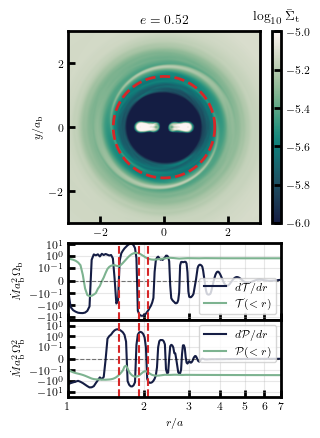

In [12]:
# Mdrop     = [6.454004361716007e-08, 6.454004361716007e-08, 6.454004361716007e-08,
#              2.065281395749122e-06, 2.065281395749122e-06, 2.065281395749122e-06,
#              6.608900466397191e-05, 6.608900466397191e-05, 6.608900466397191e-05]
# index     = 5
# Mdot_0    = Mdot0 = [0.0054329053152425390, 0.0001697782911013293, 5.305571596916542e-06]

# Calibration
cmap   = cmocean.cm.tempo_r
colors = [cmap(i / 1.5) for i in range(0,2)]
_lw    = 1.8   # main data lines
_lw_r  = 1.1   # reference/theory lines
_fa    = 0.10  # fill_between alpha
_c_ref = '#777777'
_hot   = plt.cm.hot

Mdrop     = 2.065281395749122e-06
Mdot_0    = 0.0001697782911013293
DiskStats = Averaged_Disk_Profiles[0]
Sigma_co  = DiskStats['Sigma_co']    * Mdrop**(3./5.)
Press_co  = DiskStats['Pressure_co'] * Mdrop
Vx_co     = DiskStats['Vx_co']
Vy_co     = DiskStats['Vy_co']
Div_v     = DiskStats['Div_v']
Radius    = DiskStats['Radius']
x         = np.linspace(-Radius[-1], Radius[-1], np.shape(Sigma_co)[0])
y         = np.linspace(-Radius[-1], Radius[-1], np.shape(Sigma_co)[1])
f         = np.log10(Sigma_co)

ColourbarLabel = r'$\log_{10}\bar\Sigma_\mathrm{t}$'
title          = 'Time Averaged Surface Density'



fig = plt.figure(figsize=(0.55 * text_width,  text_width))
gs  = fig.add_gridspec(3, 1, height_ratios=[0.6, 0.2, 0.2], hspace=0.0, wspace=0.1)
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])

extent = x[0], x[-1], y[0], y[-1]
cm     = ax0.imshow(
    f,
    origin="lower",
    vmin=-6,
    vmax=-5,
    cmap=cmocean.cm.tempo_r,
    extent=extent,
)
from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax0)
cax = divider.append_axes("right", size="5%", pad=0.12)
cbar = fig.colorbar(cm, cax=cax)
cax.set_position([0.95, 0.3, 0.1, 0.6])
cbar.ax.set_title(ColourbarLabel, pad=8)          # puts text above the bar
ax0.tick_params(axis='x')
ax0.tick_params(axis='y')
ax0.set_aspect("equal")
ax0.set_ylabel(r'$y/a_\mathrm{b}$')        
ax0.set_title(r'$e = 0.52$')
ax0.set_yticks([-2, 0, 2])
ax0.plot([1.59 * np.cos(t) for t in np.linspace(0, 2*np.pi, 1000)], 
         [1.59 * np.sin(t) for t in np.linspace(0, 2*np.pi, 1000)],
         c = 'tab:red',
         lw = 2.0,
         linestyle='dashed')

ax0.set_xlim(-3, 3)
ax0.set_ylim(-3, 3)
        
r_mid = 0.5 * (DiskStats['Radius'][:-1] + DiskStats['Radius'][1:])
dr    = DiskStats['Radius'][1] - DiskStats['Radius'][0]

dTdr = DiskStats['dT_dlnr'] / (r_mid * dr)
dPdr = DiskStats['dP_dlnr'] / (r_mid * dr)

ax1.plot(r_mid, dTdr / Mdot_0,                color=colors[0], lw=1.5, label=r'$d\mathcal{T}/dr$')
ax1.plot(r_mid, np.cumsum(dTdr * dr) / Mdot_0,color=colors[1], lw=1.5, label=r'$\mathcal{T}(<r)$')
ax1.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax1.set_ylabel(r'$\dot{M}a_\mathrm{b}^2\Omega_\mathrm{b}$')
ax1.tick_params(labelbottom=False)
ax1.grid(True, alpha=0.3)

ax1.axvline(x=1.59, linestyle='dashed', linewidth=1.5, c='tab:red')
ax1.axvline(x=2.08, linestyle='dashed', linewidth=1.5, c='tab:red')
ax1.axvline(x=1.91, linestyle='dashed', linewidth=1.5, c='tab:red')

ax1.set_yscale('symlog', linthresh=0.1)
ax1.set_xscale('log')
ax1.set_xlim([1, 7])
ax1.set_xticks([1,2,3,4,5,6,7])
ax1.set_xticklabels(['1','2','3','4','5','6','7'])
ax1.legend(loc='lower right')

ax2.plot(r_mid, dPdr / Mdot_0,                 color=colors[0], lw=1.5, label=r'$d\mathcal{P}/dr$')
ax2.plot(r_mid, np.cumsum(dPdr * dr) / Mdot_0, color=colors[1], lw=1.5, label=r'$\mathcal{P}(<r)$')
ax2.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax2.set_xlabel(r'$r/a$')
ax2.set_ylabel(r'$\dot{M}a_\mathrm{b}^2\Omega_\mathrm{b}^2$')
ax2.grid(True, alpha=0.3)
ax2.set_yscale('symlog', linthresh=0.1)
ax2.set_xscale('log')

ax2.axvline(x=1.59, linestyle='dashed', linewidth=1.5, c='tab:red')
ax2.axvline(x=2.08, linestyle='dashed', linewidth=1.5, c='tab:red')
ax2.axvline(x=1.91, linestyle='dashed', linewidth=1.5, c='tab:red')

ax2.set_xlim([1,7])
ax2.set_xticks([1,2,3,4,5,6,7])
ax2.set_xticklabels(['1','2','3','4','5','6','7'])
ax2.legend(loc='upper right')





plt.savefig('TimeAveraged_Density.png', dpi = 400, bbox_inches='tight')


## Accretion Timeseries

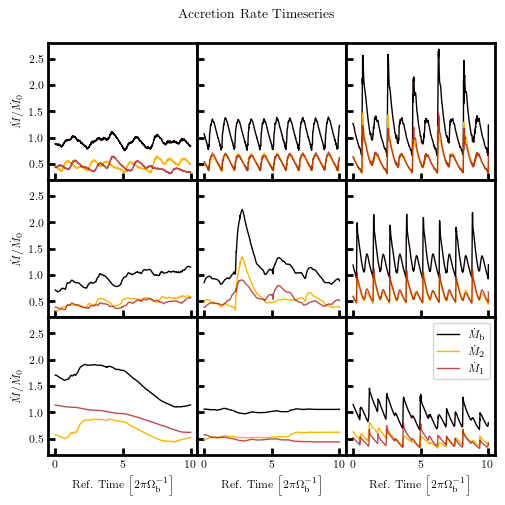

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(text_width, text_width), dpi=100,
                         sharex=True, sharey=True,
                         height_ratios=[0.33, 0.33, 0.33],
                         gridspec_kw={'hspace': 0.0, 'wspace': 0.0})
axes_flat = axes.flatten()


for index in range(9):
    ax     = axes_flat[index]

    ts            = DavidTimeseries(data[Names[index]])
    SS73          = ts.SS73
    M_dot_0       = SS73.Mdot_inf
    cmap          = plt.cm.hot

    Accretion_1   = -(np.array(ts.mdot1[-1000:])) / M_dot_0
    Accretion_2   = -(np.array(ts.mdot2[-1000:])) / M_dot_0
    AccretionRate = Accretion_1 + Accretion_2 

    Times = np.linspace(0, 10, 1000)
    ax.plot(Times, AccretionRate, label=r'$\dot{M}_\mathrm{b}$' , linewidth = 1.0, c = cmap(0.0/3)  )
    ax.plot(Times, Accretion_2  , label=r'$\dot{M}_2$'          , linewidth = 1.0, c = cmap(1.9/3))
    ax.plot(Times, Accretion_1  , label=r'$\dot{M}_1$'          , linewidth = 1.0, c = cmap(0.7/3), alpha = 0.7)
 
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    ax.set_aspect('auto')

axes_flat[0].set_ylabel(r'$\dot{M} / \dot{M}_0$')
axes_flat[3].set_ylabel(r'$\dot{M} / \dot{M}_0$')
axes_flat[6].set_ylabel(r'$\dot{M} / \dot{M}_0$')

axes_flat[6].set_xlabel(r'Ref. Time $\left[2 \pi \Omega_\mathrm{b}^{-1}\right]$')
axes_flat[7].set_xlabel(r'Ref. Time $\left[2 \pi \Omega_\mathrm{b}^{-1}\right]$')
axes_flat[8].set_xlabel(r'Ref. Time $\left[2 \pi \Omega_\mathrm{b}^{-1}\right]$')

axes_flat[8].legend()
fig.suptitle('Accretion Rate Timeseries', y=0.995)

plt.tight_layout()
plt.savefig('AccretionTimeseries.png', dpi=400)


# Torque Estimate Versus Simulations

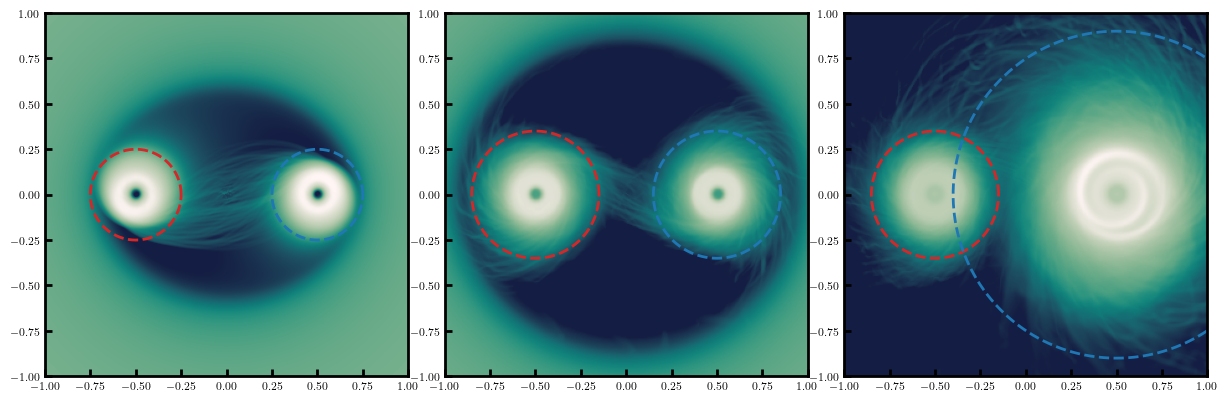

In [12]:
fig = plt.figure(figsize=(3 * text_width,  text_width))
gs  = fig.add_gridspec(1, 3, height_ratios=[1.0], hspace=0.0, wspace=0.1)
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])

Mdrop  = [6.454004361716007e-08, 2.065281395749122e-06, 6.608900466397191e-05]
Radius = Averaged_Disk_Profiles[0]['Radius'][-1]
extent = -Radius, Radius, -Radius, Radius
f0     = np.log10(Averaged_Disk_Profiles[0]['Sigma_co'] * Mdrop[0]**(3./5.))
f1     = np.log10(Averaged_Disk_Profiles[3]['Sigma_co'] * Mdrop[1]**(3./5.))
f2     = np.log10(Averaged_Disk_Profiles[6]['Sigma_co'] * Mdrop[2]**(3./5.))
cm     = ax0.imshow(
    f0,
    origin="lower",
    vmin=-7,
    vmax=-4,
    cmap=cmocean.cm.tempo_r,
    extent=extent,
)
cm     = ax1.imshow(
    f1,
    origin="lower",
    vmin=-7,
    vmax=-4,
    cmap=cmocean.cm.tempo_r,
    extent=extent,
)
cm     = ax2.imshow(
    f2,
    origin="lower",
    vmin=-7,
    vmax=-4,
    cmap=cmocean.cm.tempo_r,
    extent=extent,
)

ax0.set_xlim(-1.0, 1.0)
ax0.set_ylim(-1.0, 1.0)
ax1.set_xlim(-1.0, 1.0)
ax1.set_ylim(-1.0, 1.0)
ax2.set_xlim(-1.0, 1.0)
ax2.set_ylim(-1.0, 1.0)

r1a, r1b = 0.25, 0.25
ax0.plot([r1a * np.cos(t)-0.5 for t in np.linspace(0, 2*np.pi, 1000)], [r1a * np.sin(t) for t in np.linspace(0, 2*np.pi, 1000)], c = 'tab:red' , lw = 2.0, linestyle='dashed')
ax0.plot([r1b * np.cos(t)+0.5 for t in np.linspace(0, 2*np.pi, 1000)], [r1b * np.sin(t) for t in np.linspace(0, 2*np.pi, 1000)], c = 'tab:blue', lw = 2.0, linestyle='dashed')

r1a, r1b = 0.35, 0.35
ax1.plot([r1a * np.cos(t)-0.5 for t in np.linspace(0, 2*np.pi, 1000)], [r1a * np.sin(t) for t in np.linspace(0, 2*np.pi, 1000)], c = 'tab:red' , lw = 2.0, linestyle='dashed')
ax1.plot([r1b * np.cos(t)+0.5 for t in np.linspace(0, 2*np.pi, 1000)], [r1b * np.sin(t) for t in np.linspace(0, 2*np.pi, 1000)], c = 'tab:blue', lw = 2.0, linestyle='dashed')

r1a, r1b = 0.35, 0.9
ax2.plot([r1a * np.cos(t)-0.5 for t in np.linspace(0, 2*np.pi, 1000)], [r1a * np.sin(t) for t in np.linspace(0, 2*np.pi, 1000)], c = 'tab:red' , lw = 2.0, linestyle='dashed')
ax2.plot([r1b * np.cos(t)+0.5 for t in np.linspace(0, 2*np.pi, 1000)], [r1b * np.sin(t) for t in np.linspace(0, 2*np.pi, 1000)], c = 'tab:blue', lw = 2.0, linestyle='dashed')


In [18]:
0.2**0.5

0.4472135954999579

Pair 0.25 0.25
Pair 0.35 0.35
Pair 0.38 0.8


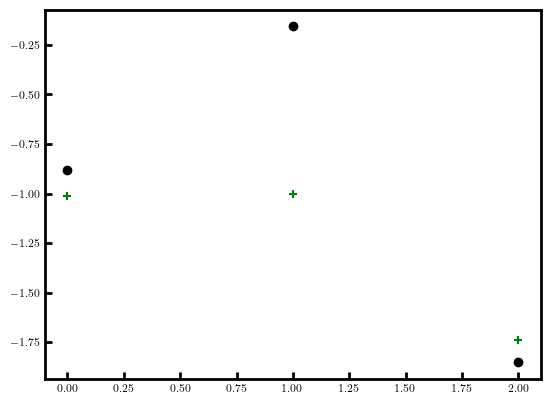

In [ ]:
def ProcessTorqueTimeseries(chkpt, Number_of_Orbits):
    timeseries_data  = chkpt['timeseries']
    SS73             = chkpt["SS73"]

    mdot1            = np.array([s[12] for s in timeseries_data])
    mdot2            = np.array([s[13] for s in timeseries_data])
    torque_g         = np.array([s[14] for s in timeseries_data])
    torque_a         = np.array([s[15] for s in timeseries_data])
    time             = np.array([s[0] for s in timeseries_data])
    Final_Orbits     = time[time>(time[-1]-Number_of_Orbits)]

    Torque              = -(torque_g[-len(Final_Orbits):] + torque_a[-len(Final_Orbits):]) / SS73.Mdot_inf
    #Power               = -(np.array(ts.power_g[-len(Final_Orbits):] ) + np.array(ts.power_a[-len(Final_Orbits):] )) / M_dot_0
    Accretion_1         = -mdot1 / SS73.Mdot_inf
    Accretion_2         = -mdot2 / SS73.Mdot_inf
    Mdot                = Accretion_1 + Accretion_2    

    return Final_Orbits, Torque, np.mean(Torque), np.mean(Mdot)

def EstimatEll0Analytical(rho1, rho2, eta1, eta2):
    rhomax = np.max([rho1, rho2])
    li     =-np.sqrt(0.5 + rhomax)
    lf     = 0.5 + eta1 * np.sqrt(rho1/2) + eta2 * np.sqrt(rho2/2)
    
    return -(lf - li)



MinidiskSize = [0.25, 0.25, 0.35, 0.35, 0.38, 0.8]
eta          = [-0.5, -0.5, 0.5, 0.5, 0.5, -0.5]

for index in range(3):
    Final_Orbits, Torque, MeanTorque, MeanMdot = ProcessTorqueTimeseries(data[Names[3*index]], Number_of_Orbits=100)

    r1   = MinidiskSize[2*index]
    r2   = MinidiskSize[1 + 2*index]
    eta1 = eta[index//2]
    eta2 = eta[1 + index//2]
    print('Pair', r1, r2)
    AnalyticalEll0 = EstimatEll0Analytical(rho1=r1, rho2=r2, eta1=eta1, eta2=eta2)
    
    
    plt.scatter(index, AnalyticalEll0, marker='+', c='green')
    plt.scatter(index, MeanTorque/MeanMdot, marker='o', c='black')


plt.show()

In [ ]:
# time averaged subdirectories,
Host   = '/mnt/beegfs/haimagrp/david_oneill/sailfish/Retrograde/Fixed_e/'
Branch = ['e00Mach10', 'e03Mach10', 'e06Mach10',
          'e00Mach20', 'e03Mach20', 'e06Mach20',
          'e00Mach40', 'e03Mach40', 'e06Mach40']

def _process_branch(index, Nbins=500):
    LoadingDirectory = '/mnt/beegfs/haimagrp/david_oneill/sailfish/Retrograde/Sweeps/Mach20/ResonantTorque/'
    checkpoint_files = sorted(glob.glob(LoadingDirectory + 'chkpt.*.pk'))
    Sigma, Vx, Vy, Pressure, mesh, SS73, gamma, r_mid, FJ_r, Sigma_co, Pressure_co, Vx_co, Vy_co, Div_v, r_bins = TimeAverage(checkpoint_files, Nbins)
    print('Time Averaged        ' + Branch[index])
    DiskStats = AzimuthallyAverageCBD(Sigma, Vx, Vy, Pressure, mesh, SS73, gamma, r_bins)
    DiskStats.update({'Sigma_co': Sigma_co, 'Pressure_co': Pressure_co,
                      'Vx_co': Vx_co, 'Vy_co': Vy_co, 'Div_v': Div_v,
                      'FJ_Rey': FJ_r, 'FJ_Rad': r_mid, 'Radius': r_bins})
    print('Azimuthally Averaged ' + Branch[index])
    return DiskStats

def TimeAverage(checkpoint_files, Nbins):
    sigma_sum = press_sum = vx_sum = vy_sum = None
    sigma_co = vx_co = vy_co = press_co = div_v_co = None
    Fj_r = None
    mesh = r_bins = None

    for f in checkpoint_files:
        chkpt = load_checkpoint(f)
        sigma = chkpt["solution"][:, :, 0].T
        vx    = chkpt['solution'][:, :, 1].T
        vy    = chkpt['solution'][:, :, 2].T
        press = chkpt["solution"][:, :, 3].T
        if sigma_sum is None:
            mesh   = chkpt["mesh"]
            r_bins = np.linspace(0., mesh.x1, Nbins)
            sigma_sum, press_sum, vx_sum, vy_sum = sigma, press, vx, vy
            _, fj_r = compute_FJ_profile(sigma, vx, vy, mesh, r_bins)
            Fj_r    = fj_r
            corot   = make_corotating_maps(sigma, vx, vy, press, mesh, chkpt['point_masses'])
            sigma_co, vx_co, vy_co, press_co, div_v_co = corot[2], corot[3], corot[4], corot[5], corot[6]
        else:
            sigma_sum += sigma; press_sum += press; vx_sum += vx; vy_sum += vy
            _, fj_r  = compute_FJ_profile(sigma, vx, vy, mesh, r_bins)
            Fj_r    += fj_r
            corot    = make_corotating_maps(sigma, vx, vy, press, mesh, chkpt['point_masses'])
            sigma_co += corot[2]; vx_co += corot[3]; vy_co += corot[4]
            press_co += corot[5]; div_v_co += corot[6]

    n     = len(checkpoint_files)
    r_mid = 0.5 * (r_bins[:-1] + r_bins[1:])
    return (sigma_sum/n, vx_sum/n, vy_sum/n, press_sum/n,
            chkpt["mesh"], chkpt["SS73"], chkpt['model_parameters']['gamma_law_index'],
            r_mid, Fj_r/n, sigma_co/n, press_co/n, vx_co/n, vy_co/n, div_v_co/n, r_bins)

def make_corotating_maps(sigma, vx, vy, press, mesh, pointmasses):
    ni, nj = mesh.shape
    x      = np.array([mesh.cell_coordinates(i, 0)[0] for i in range(ni)])
    y      = np.array([mesh.cell_coordinates(0, j)[1] for j in range(nj)])
    X, Y   = np.meshgrid(x, y)
    R      = np.sqrt(X**2 + Y**2)
    r_max  = x[-1]

    primary, secondary = pointmasses 
    phi = np.arctan2(primary.position_y, primary.position_x)

    # Step 1: subtract frame angular velocity  v_corot = v_inertial - omega x r 
    Omega_b = (primary.position_x * primary.velocity_y - primary.position_y * primary.velocity_x)/(primary.position_y**2 + primary.position_x**2)
    vx_f   = vx + Omega_b * Y
    vy_f   = vy - Omega_b * X

    # Step 2: project onto co-rotating axes
    c, s     = np.cos(phi), np.sin(phi)
    vx_corot =  c * vx_f + s * vy_f
    vy_corot = -s * vx_f + c * vy_f

    # Step 3: rotate fields spatially so binary sits on +x axis
    angle_deg = np.degrees(phi)

    def _rot(field):
        return nd_rotate(field, angle_deg, reshape=False, mode='constant', cval=0.0)

    sigma_rot = _rot(sigma)
    vx_rot    = _rot(vx_corot)
    vy_rot    = _rot(vy_corot)
    press_rot = _rot(press)

    # Step 4: mask corners beyond r_max
    mask = R > r_max
    for arr in (sigma_rot, vx_rot, vy_rot, press_rot):
        arr[mask] = np.nan

    dx    = x[1] - x[0]
    dy    = y[1] - y[0]
    div_v = np.gradient(vx_rot, dx, axis=1) + np.gradient(vy_rot, dy, axis=0)
    return (x, y, sigma_rot, vx_rot, vy_rot, press_rot, div_v)




def compute_FJ_profile(Sigma, Vx, Vy, mesh, r_bins):
    x = np.array([mesh.cell_coordinates(i, 0)[0] for i in range(mesh.shape[0])])
    y = np.array([mesh.cell_coordinates(0, j)[1] for j in range(mesh.shape[1])])
    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)

    Vr   = (X * Vx + Y * Vy) / np.where(R == 0, np.nan, R)
    Vphi = (-Y * Vx + X * Vy) / np.where(R == 0, np.nan, R)

    r_mid = 0.5 * (r_bins[:-1] + r_bins[1:])
    flat  = slice(None)  # keep flat views

    idx   = np.digitize(R.ravel(), r_bins) - 1
    valid = (idx >= 0) & (idx < len(r_mid)) & ~np.isnan(R.ravel())
    idx, S, vr, vp = idx[valid], Sigma.ravel()[valid], Vr.ravel()[valid], Vphi.ravel()[valid]

    nb = len(r_mid)
    cnt   = np.bincount(idx, minlength=nb).astype(float)
    wS    = np.bincount(idx, weights=S,    minlength=nb)
    wSvr  = np.bincount(idx, weights=S*vr, minlength=nb)
    wSvp  = np.bincount(idx, weights=S*vp, minlength=nb)

    good      = cnt >= 8
    mean_vr   = np.where(good, wSvr / np.where(wS > 0, wS, np.nan), np.nan)
    mean_vp   = np.where(good, wSvp / np.where(wS > 0, wS, np.nan), np.nan)

    dvr = vr - mean_vr[idx]
    dvp = vp - mean_vp[idx]

    wFlux = np.bincount(idx, weights=S * dvr * dvp, minlength=nb)
    FJ_r  = np.where(good, 2 * np.pi * r_mid**2 * wFlux / cnt, np.nan)

    return r_mid, FJ_r

def AzimuthallyAverageCBD(Sigma, Vx, Vy, Pressure, mesh, SS73, gamma, r_bins):
    Mdrop   = SS73.Mdrop
    cs      = (gamma * Pressure / Sigma)**0.5
    ni, nj  = mesh.shape
    x = np.array([mesh.cell_coordinates(i, 0)[0] for i in range(ni)])
    y = np.array([mesh.cell_coordinates(0, j)[1] for j in range(nj)])
    X, Y    = np.meshgrid(x, y, indexing="xy")
    Sigma   = Sigma   * SS73.surface_density_coefficient
    Pressure= Pressure* SS73.surface_pressure_coefficient
    R       = np.sqrt(X**2 + Y**2)
    speed   = np.sqrt(Vx**2 + Vy**2)
    vr      = (Vx*X + Vy*Y) / R
    ang_mom = X*Vy - Y*Vx
    v_dot_v = speed**2;  v_dot_r = Vx*X + Vy*Y
    ex      = v_dot_v*X - v_dot_r*Vx - X/R
    ey      = v_dot_v*Y - v_dot_r*Vy - Y/R
    e       = np.sqrt(ex**2 + ey**2)
    mach    = speed / cs

    r_flat = R.ravel()
    arrays = {
        'V': speed.ravel(), 
        'E': e.ravel(),
        'D': (Sigma * Mdrop**(3/5)).ravel(),
        'M': mach.ravel(),   
        'Vr': vr.ravel(),
        'l': ang_mom.ravel(),
        'P': (Pressure * Mdrop).ravel(),
    }

    DiskStats = {}
    for name, arr in arrays.items():
        for stat, prefix in [('median', 'Median'), ('min', 'Min'), ('max', 'Max')]:
            vals, _, _ = binned_statistic(r_flat, arr, statistic=stat, bins=r_bins)
            DiskStats[f'{prefix}{name}'] = list(vals)

    return DiskStats

if False:
    Averaged_Disk_Profiles = ProcessTimeAzimuthalAverages(save=True)
else:
    with open('disk_profiles.pkl', 'rb') as f:
        Averaged_Disk_Profiles = pickle.load(f)

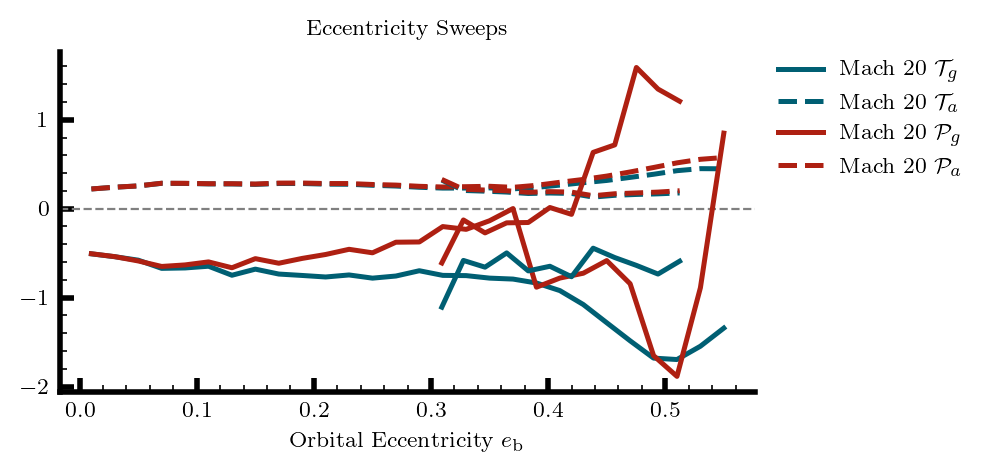

In [12]:
def ComputeTorquePower_GravAccret(checkpoint):
    ts                  = DavidTimeseries(checkpoint)
    SS73                = ts.SS73
    M_dot_0             = SS73.Mdot_inf
    Final_Orbits        = ts.eccentricity[ts.eccentricity>0.0001]

    primary, secondary  = ts.pointmasses
    m1, m2              = primary.mass, secondary.mass
    M, G                = m1 + m2, 1.0
    q                   = m2 / m1                                            # mass ratio
    mu                  = m1 * m2 / M                                        # reduced mass
    Torque_g            = -np.array(ts.torque_g[-len(Final_Orbits):]) / M_dot_0
    Torque_a            = -np.array(ts.torque_a[-len(Final_Orbits):]) / M_dot_0
    Power_g             = -np.array(ts.power_g[-len(Final_Orbits):] ) / M_dot_0
    Power_a             = -np.array(ts.power_a[-len(Final_Orbits):] ) / M_dot_0
    e                   = np.array(ts.eccentricity[-len(Final_Orbits):])
    return e, Torque_g, Torque_a, Power_g, Power_a


Mach10_e , Mach10_TG , Mach10_TA , Mach10_PG , Mach10_PA   = ComputeTorquePower_GravAccret(Mach10Sweep)
Mach20_ea, Mach20_TGa, Mach20_TAa, Mach20_PGa, Mach20_PAa  = ComputeTorquePower_GravAccret(Mach20Sweep_a)
Mach20_eb, Mach20_TGb, Mach20_TAb, Mach20_PGb, Mach20_PAb  = ComputeTorquePower_GravAccret(Mach20Sweep_b)


fig, ax  = plt.subplots(figsize=[text_width, column_width],  dpi=200)
savename = 'Gravity_vs_Accretion'

_adot_dark  = '#2166AC'  # deep blue
_adot_light = '#6BAED6'  # medium cornflower blue

_edot_dark  = '#B2182B'  # deep crimson
_edot_light = '#EF8A62'  # warm salmon-orange


_adot_dark  = '#2166AC'  # deep blue
_adot_light = '#74ADD1'  # sky blue

_edot_dark  = '#1A7B35'  # deep forest green
_edot_light = '#74C476'  # medium sage green


_adot_dark  = '#005F73'  # deep teal
_adot_light = '#94D2BD'  # pale teal

_edot_dark  = '#AE2012'  # deep brick red
_edot_light = '#E05C1A'  # amber-orange


Mach10_ea , Mach10_mtg, _ = ComputeBinnedStats(Mach10_e , Mach10_TG , 0.02)
Mach10_ea , Mach10_mta, _ = ComputeBinnedStats(Mach10_e , Mach10_TA , 0.02)
Mach10_ea , Mach10_mpg, _ = ComputeBinnedStats(Mach10_e , Mach10_PG , 0.02)
Mach10_ea , Mach10_mpa, _ = ComputeBinnedStats(Mach10_e , Mach10_PA , 0.02)

Mach20_eaa, Mach20_mtga, _ = ComputeBinnedStats(Mach20_ea, Mach20_TGa , 0.02)
Mach20_eaa, Mach20_mtaa, _ = ComputeBinnedStats(Mach20_ea, Mach20_TAa , 0.02)
Mach20_eaa, Mach20_mpga, _ = ComputeBinnedStats(Mach20_ea, Mach20_PGa , 0.02)
Mach20_eaa, Mach20_mpaa, _ = ComputeBinnedStats(Mach20_ea, Mach20_PAa , 0.02)

Mach20_eab, Mach20_mtgb, _ = ComputeBinnedStats(Mach20_eb, Mach20_TGb , 0.02)
Mach20_eab, Mach20_mtab, _ = ComputeBinnedStats(Mach20_eb, Mach20_TAb , 0.02)
Mach20_eab, Mach20_mpgb, _ = ComputeBinnedStats(Mach20_eb, Mach20_PGb , 0.02)
Mach20_eab, Mach20_mpab, _ = ComputeBinnedStats(Mach20_eb, Mach20_PAb , 0.02)

ax.plot(Mach20_eaa, Mach20_mtga, linewidth=1.8, linestyle='solid', color=_adot_dark , zorder=3, label=r'Mach 20 $\mathcal{T}_g$')
ax.plot(Mach20_eaa, Mach20_mtaa, linewidth=1.8, linestyle='dashed', color=_adot_dark , zorder=3, label=r'Mach 20 $\mathcal{T}_a$')
ax.plot(Mach20_eaa, Mach20_mpga, linewidth=1.8, linestyle='solid', color=_edot_dark, zorder=3, label=r'Mach 20 $\mathcal{P}_g$')
ax.plot(Mach20_eaa, Mach20_mpaa, linewidth=1.8, linestyle='dashed', color=_edot_dark, zorder=3, label=r'Mach 20 $\mathcal{P}_a$')

ax.plot(Mach20_eab, Mach20_mtgb, linewidth=1.8, linestyle='solid', color=_adot_dark , zorder=3)
ax.plot(Mach20_eab, Mach20_mtab, linewidth=1.8, linestyle='dashed', color=_adot_dark , zorder=3)
ax.plot(Mach20_eab, Mach20_mpgb, linewidth=1.8, linestyle='solid', color=_edot_dark, zorder=3)
ax.plot(Mach20_eab, Mach20_mpab, linewidth=1.8, linestyle='dashed', color=_edot_dark, zorder=3)




ax.autoscale()
_ylo, _yhi = ax.get_ylim()

ax.set_ylim(_ylo, _yhi)   
ax.axhline(y=0, color='0.5', linewidth=0.8, linestyle='--', zorder=2)

ax.set_xlabel('Orbital Eccentricity $e_\mathrm{b}$')
ax.set_title(r'Eccentricity Sweeps', fontsize=8)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0,frameon=True, framealpha=0.9, edgecolor='none')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(which='both', top=False, right=False)
ax.minorticks_on()
ax.tick_params(which='minor', length=2.5, direction='in')
fig.tight_layout()


plt.tight_layout()
plt.savefig('Gravity_vs_accretion', dpi=300)


## Strictly Periodic Orbits

In [60]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
import matplotlib.pyplot as plt

MU = 0.5 


# ---------------------------------------------------------------------------
# Equations of motion
# ---------------------------------------------------------------------------

def eom_corot(t, state):
    """
    Equations of motion in the co-rotating (synodic) frame of the binary.

    The standard CR3BP equations of motion are (Szebehely 1967):
        xddot = 2*ydot + x - (1-mu)*(x+mu)/r1^3 - mu*(x-(1-mu))/r2^3
        yddot = -2*xdot + y - (1-mu)*y/r1^3     - mu*y/r2^3

    where r1 and r2 are the distances from the test particle to m1 and m2.

    Parameters
    ----------
    t : float
        Current time (not used explicitly; equations are autonomous).
    state : array-like, shape (4,)
        Current state vector [x, y, xdot, ydot].

    Returns
    -------
    list of length 4
        Time derivatives [xdot, ydot, xddot, yddot].
    """
    x, y, xdot, ydot = state

    # Distances from test particle to each primary
    r1 = np.sqrt((x + MU)**2        + y**2)   # distance to m1 at (-0.5, 0)
    r2 = np.sqrt((x - (1 - MU))**2  + y**2)   # distance to m2 at (+0.5, 0)

    # Accelerations (Coriolis + centrifugal + gravity from both masses)
    ax = (  2*ydot + x
          - (1 - MU) * (x + MU)       / r1**3
          - MU       * (x - (1 - MU)) / r2**3)

    ay = ( -2*xdot + y
          - (1 - MU) * y / r1**3
          - MU       * y / r2**3)

    return [xdot, ydot, ax, ay]


# ---------------------------------------------------------------------------
# Shooting function
# ---------------------------------------------------------------------------

def shoot(ydot0, x0, t_max=200.0):
    """
    Shooting function for a retrograde circumsingle periodic orbit around m2.

    Launches the test particle from (x0, 0) with velocity (0, ydot0) --
    i.e. perpendicularly off the x-axis -- and integrates forward until the
    orbit returns to y = 0.  For a periodic orbit the x-velocity at that
    return crossing must be zero (x-axis symmetry condition).

    The integration is done in two steps:
        1. A tiny step away from t=0 to avoid immediately re-triggering the
           y=0 event at the launch point.
        2. The main integration with a terminal y=0 event detector.

    Parameters
    ----------
    ydot0 : float
        Initial y-velocity.  Should be negative for a retrograde orbit.
    x0 : float
        Launch point on the x-axis.  Must satisfy x0 > 0.5 for a
        circumsingle orbit around m2 at x = +0.5.
    t_max : float, optional
        Maximum integration time in units of the binary period.
        Default is 200.

    Returns
    -------
    float
        The x-velocity xdot at the return y=0 crossing.
        Returns np.nan if no return crossing is found within t_max.
    """
    state0 = [x0, 0.0, 0.0, ydot0]

    # --- Step 1: tiny integration to step past the t=0 launch point --------
    #solve_ivp(fun, t_span, y0, method='RK45', t_eval=None, dense_output=False, events=None, vectorized=False, args=None, **options)
    tiny_step = solve_ivp(eom_corot, [0.0, 1e-4], state0, method='DOP853', rtol=1e-11, atol=1e-13)

    # --- Step 2: integrate until y=0 again (terminal event) ----------------
    def y_zero(t, s):
        """Event function: triggers when the orbit crosses y = 0."""
        return s[1]   # y-component of state

    y_zero.terminal  = True    # stop integration at first y=0 crossing
    y_zero.direction = +1      # only trigger when y crosses 0 from below
                               # (i.e. the orbit returns from negative y)

    sol = solve_ivp(
        eom_corot,
        [tiny_step.t[-1], t_max],
        tiny_step.y[:, -1],
        method='DOP853',
        events=y_zero,
        rtol=1e-11, atol=1e-13,
        dense_output=True
    )

    if len(sol.t_events[0]) == 0:
        # No return crossing found -- orbit may have escaped or t_max too small
        return np.nan

    # Evaluate state at the return crossing and return xdot
    t_return     = sol.t_events[0][0]
    state_return = sol.sol(t_return)
    return state_return[2]   # xdot at return crossing


# ---------------------------------------------------------------------------
# Compute the family
# ---------------------------------------------------------------------------

def compute_family(x0_values):
    """
    Compute the retrograde circumsingle periodic orbit family around m2.

    For each launch radius x0 in x0_values, finds the unique retrograde
    initial y-velocity ydot0 < 0 such that the orbit is periodic (xdot = 0
    at the return y=0 crossing).  Uses brentq to root-find the shooting
    condition.

    The initial bracket for brentq is constructed around the Keplerian
    estimate

        v_kep = sqrt(mu / r)

    and the frame rotation subtracts Omega * x0 = x0 from the tangential
    (y) velocity at a point on the x-axis.  For a retrograde orbit ydot < 0
    so the frame correction adds to the magnitude:

        ydot_guess = -(v_kep + x0)

    This is only approximate; brentq corrects for the binary perturbation.

    Parameters
    ----------
    x0_values : array-like
        Launch radii on the x-axis, in units of a_b.  Should all exceed 0.5.

    Returns
    -------
    list of scipy.integrate.OdeSolution
        One integrated orbit solution per successfully converged launch radius.
    list of float
        The corresponding converged ydot0 values.
    """
    orbits    = []
    ydot_sols = []

    for x0 in x0_values:
        r          = x0 - 0.5                     # distance from m2
        ydot_guess = -(np.sqrt(MU / r) + x0)      # Keplerian + frame correction

        
        # Root-find: shoot() should change sign across the periodic solution
        try:
            Disregard = False
            ydot_sol = brentq(
                shoot,
                ydot_guess * 0.75,
                ydot_guess * 1.25,
                args=(x0,),
                xtol=1e-16,
                maxiter=500
            )
        
        except Exception as e:
            Disregard = True
            ydot_sol  = 1.0

        # Integrate one full period for plotting.
        # We stop when the orbit returns to y=0 with ydot>0 (full period).
        def y_zero_full(t, s): return s[1]
        y_zero_full.terminal  = True
        y_zero_full.direction = +1

        # Step past launch point first
        tiny = solve_ivp(
            eom_corot, [0.0, 1e-4], [x0, 0.0, 0.0, ydot_sol],
            method='DOP853', rtol=1e-11, atol=1e-13
        )
        sol = solve_ivp(
            eom_corot,
            [tiny.t[-1], 200.0],
            tiny.y[:, -1],
            method='DOP853',
            events=y_zero_full,
            rtol=1e-11, atol=1e-13,
            dense_output=True,
            max_step=1e-3
        )
        
        if Disregard:
            sol["success"] = False

        #else:
        #    print(f"x0 = {x0:.3f}  ydot0 = {ydot_sol:.6f}  period ~ {2*sol.t[-1]:.4f} T_bin")
        
        orbits.append(sol)
        ydot_sols.append(ydot_sol)
        

    return orbits, ydot_sols


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------

if __name__ == "__main__":

    # Launch radii: from just outside m2 (x=0.5) up to the Hill radius.
    # The Hill radius of m2 in an equal-mass binary is approximately
    # r_Hill ~ 0.5 * (mu/3)^(1/3) * a_b ~ 0.38 a_b, so x0 < ~0.88.
    # We stay comfortably inside that limit.
    
    #x0_values = np.linspace(0.52, 1.73, 30)
    x0_values = np.linspace(0.52, 1.739580905, 30)

    orbits, ydot_sols = compute_family(x0_values)
    

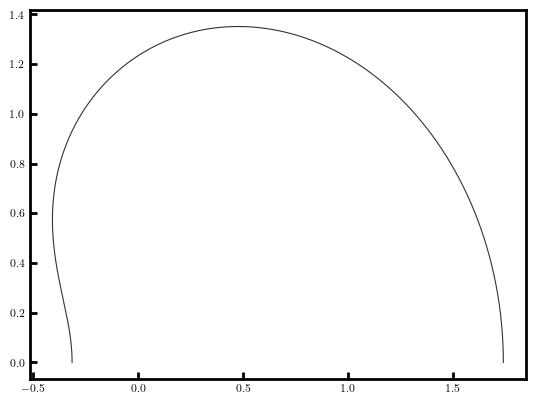

In [61]:
plt.plot(orbits[-1].y[0], -orbits[-1].y[1], c='black', lw=0.8, alpha=0.8, zorder=1)

## Minidisk Analysis

In [ ]:
# --- Minidisk Profile Analysis ---
RMinidisk          = 0.55
primary, secondary = chkpt['point_masses']
SinkRadius         = (primary.sink_radius,      secondary.sink_radius)
SoftRadius         = (primary.softening_length, secondary.softening_length)
RadialBins_md      = np.linspace(0, RMinidisk, int((RMinidisk / (mesh.x1 - mesh.x0)) * ni))
GMu_primary        = primary.mass
GMu_secondary      = secondary.mass

r_primary        = [X - primary.position_x,    Y - primary.position_y]
r_secondary      = [X - secondary.position_x,  Y - secondary.position_y]
V_primary        = [Vx - primary.velocity_x,   Vy - primary.velocity_y]
V_secondary      = [Vx - secondary.velocity_x, Vy - secondary.velocity_y]
primary_speed    = np.sqrt(V_primary[0]**2   + V_primary[1]**2)
secondary_speed  = np.sqrt(V_secondary[0]**2 + V_secondary[1]**2)
primary_radius   = np.sqrt(r_primary[0]**2   + r_primary[1]**2)
secondary_radius = np.sqrt(r_secondary[0]**2 + r_secondary[1]**2)

v_dot_v_primary   = primary_speed**2
v_dot_r_primary   = V_primary[0] * r_primary[0]  + V_primary[1] * r_primary[1]
ex_primary        = (v_dot_v_primary * r_primary[0]  - v_dot_r_primary * V_primary[0])  / GMu_primary  - r_primary[0]  / primary_radius
ey_primary        = (v_dot_v_primary * r_primary[1]  - v_dot_r_primary * V_primary[1])  / GMu_primary  - r_primary[1]  / primary_radius
e_primary         = np.sqrt(ex_primary**2  + ey_primary**2)
mach_primary      = primary_speed / cs
v_dot_v_secondary = secondary_speed**2
v_dot_r_secondary = V_secondary[0] * r_secondary[0] + V_secondary[1] * r_secondary[1]
ex_secondary      = (v_dot_v_secondary * r_secondary[0] - v_dot_r_secondary * V_secondary[0]) / GMu_secondary - r_secondary[0] / secondary_radius
ey_secondary      = (v_dot_v_secondary * r_secondary[1] - v_dot_r_secondary * V_secondary[1]) / GMu_secondary - r_secondary[1] / secondary_radius
e_secondary       = np.sqrt(ex_secondary**2 + ey_secondary**2)
mach_secondary    = secondary_speed / cs

keys              = ['MedianV','MinV','MaxV','MedianE','MinE','MaxE','MedianD','MinD','MaxD','MedianM','MinM','MaxM']
PrimaryMiniDisk   = {k: [] for k in keys}
SecondaryMiniDisk = {k: [] for k in keys}
for i in range(len(RadialBins_md) - 1):
    pm = (RadialBins_md[i] < primary_radius)   & (primary_radius   < RadialBins_md[i+1])
    sm = (RadialBins_md[i] < secondary_radius) & (secondary_radius < RadialBins_md[i+1])
    SaveBinStats(PrimaryMiniDisk, keys,
        [np.median(primary_speed[pm])      , np.min(primary_speed[pm])        , np.max(primary_speed[pm]),
         np.median(e_primary[pm])          , np.min(e_primary[pm])            , np.max(e_primary[pm]),
         np.median(Sigma[pm]* Mdrop**(3/5)), np.min(Sigma[pm]* Mdrop**(3./5.)), np.max(Sigma[pm]* Mdrop**(3./5.)),
         np.median(mach_primary[pm])       , np.min(mach_primary[pm])         , np.max(mach_primary[pm])])
    SaveBinStats(SecondaryMiniDisk, keys,
        [np.median(secondary_speed[sm])      , np.min(secondary_speed[sm])      , np.max(secondary_speed[sm]),
         np.median(e_secondary[sm])          , np.min(e_secondary[sm])          , np.max(e_secondary[sm]),
         np.median(Sigma[sm]* Mdrop**(3./5.)), np.min(Sigma[sm]* Mdrop**(3./5.)), np.max(Sigma[sm]* Mdrop**(3./5.)),
         np.median(mach_secondary[sm])       , np.min(mach_secondary[sm])       , np.max(mach_secondary[sm])])




# Angular Momentum Flux Calculations
G         = Sigma * vr / SS73.surface_density_coefficient     # mass flux density through circles (per area)
dx, dy    = mesh.dx, mesh.dy
dA        = dx * dy
r_flat    = radius.ravel()
G_flat    = G.ravel()
vphi_flat = vphi.ravel()

r_min, r_max = 1.0, np.max(r_flat)/np.sqrt(2)
n_bins       = min(100, mesh.shape[0] // 4)
r_bins       = np.linspace(r_min, r_max, n_bins)
mdot_ring    = np.full(n_bins-1, np.nan)
r_centers    = 0.5*(r_bins[:-1] + r_bins[1:])

for k in range(n_bins-1):
    r0, r1 = r_bins[k], r_bins[k+1]
    mask   = (r_flat >= r0) & (r_flat < r1)
    if mask.any():
        dr           = (r1 - r0)
        mdot_ring[k] = -(G_flat[mask].sum() * dA) / dr  # ≈ - (1/dr) ∫_annulus Σ v_r dA

mdot_ring_norm = mdot_ring / SS73.Mdot_inf
alpha_visc     = chkpt['model_parameters']['alpha']
P0_flat        = Pressure.ravel()  # unscaled (code-unit) pressure
FJ0_ring       = np.full(n_bins - 1, np.nan)
FJ_total_ring  = np.full(n_bins - 1, np.nan)

for k in range(n_bins - 1):
    r0, r1 = r_bins[k], r_bins[k + 1]
    mask   = (r_flat >= r0) & (r_flat < r1)
    if mask.any():
        dr                = r1 - r0
        r_k               = r_centers[k]
        FJ_visc           = (3. / 2.) * alpha_visc * gamma * r_k * (P0_flat[mask].sum() * dA) / dr
        FJ0_ring[k]       = FJ_visc - mdot_ring[k] * np.sqrt(r_k)
        # F_J = 3π ν Σ l, ν Σ = α P r^{3/2}, l = r v_φ (not assumed Keplerian)
        FJ_total_ring[k]  = (3. / 2.) * alpha_visc * gamma * np.sum(P0_flat[mask] * r_flat[mask]**(3./2.) * vphi_flat[mask]) * dA / dr

FJ0_ring_norm      = FJ0_ring      / SS73.Mdot_inf  # in steady state ≈ ell0 (const)
FJ_total_ring_norm = FJ_total_ring / SS73.Mdot_inf

In [ ]:
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle

vlim            = 1.1 * np.nanmax([np.nanmax(PrimaryMiniDisk['MaxV']),  np.nanmax(SecondaryMiniDisk['MaxV'])])
dlim            = 3.0 * np.nanmax([np.nanmax(PrimaryMiniDisk['MaxD']),  np.nanmax(SecondaryMiniDisk['MaxD'])])
PrimaryRadius   = RadialBins_md[1:] #/ SinkRadius[0]
SecondaryRadius = RadialBins_md[1:] #/ SinkRadius[1]
xlim            = max(PrimaryRadius[-1], SecondaryRadius[-1])

_c_primary   = '#1B6B3A'
_c_secondary = '#1D6FA4'
_c_ref       = '#777777'

_sig_vals = np.concatenate([Sigma[primary_radius < RMinidisk].ravel(), Sigma[secondary_radius < RMinidisk].ravel()])
_sig_vals = _sig_vals[_sig_vals > 0]
_norm     = LogNorm(vmin=1e-6, vmax=2e-2)
_mach_all = np.concatenate([PrimaryMiniDisk['MedianM'], SecondaryMiniDisk['MedianM']])
_mac_max  = np.nanpercentile(_mach_all, 90) * 1.3
_mac_min  = 0.0

def _quiver_field(pos_x, pos_y, vel_x, vel_y):
    from scipy.interpolate import RegularGridInterpolator
    _nq   = 20
    _qgrd = np.linspace(-RMinidisk, RMinidisk, _nq)
    _qX, _qY = np.meshgrid(_qgrd, _qgrd)
    rgi_u = RegularGridInterpolator((y, x), vel_x, method='linear', bounds_error=False, fill_value=np.nan)
    rgi_v = RegularGridInterpolator((y, x), vel_y, method='linear', bounds_error=False, fill_value=np.nan)
    pts   = np.column_stack([(_qY + pos_y).ravel(), (_qX + pos_x).ravel()])
    U = rgi_u(pts).reshape(_nq, _nq)
    V = rgi_v(pts).reshape(_nq, _nq)
    R   = np.sqrt(_qX**2 + _qY**2)
    spd = np.sqrt(U**2 + V**2)
    spd[spd == 0] = np.nan
    U = np.where(R < RMinidisk, U / spd, np.nan)
    V = np.where(R < RMinidisk, V / spd, np.nan)
    return _qX, _qY, U, V

_qX_p, _qY_p, _qU_p, _qV_p = _quiver_field(primary.position_x,   primary.position_y,   Vx, Vy)
_qX_s, _qY_s, _qU_s, _qV_s = _quiver_field(secondary.position_x, secondary.position_y, Vx, Vy)

fig = plt.figure(figsize=(0.8*text_width, 1.12 * text_width), dpi=150)

gs_top = fig.add_gridspec(1, 2, left=0.10, right=0.93, top=0.925, bottom=0.609, wspace=0.06)
gs_bot = fig.add_gridspec(2, 2, left=0.10, right=0.93, top=0.565, bottom=0.12, hspace=0.20, wspace=0.06)

ax_pm  = fig.add_subplot(gs_top[0, 0])
ax_sm  = fig.add_subplot(gs_top[0, 1])
ax_vel = fig.add_subplot(gs_bot[0, 0])
ax_ecc = fig.add_subplot(gs_bot[0, 1])
ax_den = fig.add_subplot(gs_bot[1, 0])
ax_mac = fig.add_subplot(gs_bot[1, 1])

# --- (i, ii) density maps ---
for ax, pos_x, pos_y, title, c, sr, lbl, qX, qY, qU, qV in [
        (ax_pm, primary.position_x,   primary.position_y,   r'$\textbf{Primary}$',   _c_primary,   SinkRadius[0], 'i',  _qX_p, _qY_p, _qU_p, _qV_p),
        (ax_sm, secondary.position_x, secondary.position_y, r'$\textbf{Secondary}$', _c_secondary, SinkRadius[1], 'ii', _qX_s, _qY_s, _qU_s, _qV_s)]:
    im = ax.pcolormesh(X - pos_x, Y - pos_y, Sigma, cmap=cmocean.cm.tempo_r, norm=_norm, shading='auto', rasterized=True)
    ax.set_xlim([-RMinidisk, RMinidisk])
    ax.set_ylim([-RMinidisk, RMinidisk])
    ax.set_aspect('equal')
    ax.tick_params(which='both', direction='in', labelsize=6, bottom=False, labelbottom=False)
    ax.quiver(qX, qY, qU, qV, color='grey', alpha=0.55, scale=28, width=0.004, headwidth=3.5, headlength=4, headaxislength=3.5, zorder=4)
    ax.add_patch(Circle((0, 0), sr, fill=False, edgecolor='black', linewidth=0.9, linestyle='dashed', zorder=5))
    ax.text(0.50, 0.96, title, transform=ax.transAxes, fontsize=8, fontweight='bold', va='top', ha='center', color=c, zorder=6, bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', boxstyle='round,pad=0.2'))
    ax.text(0.04, 0.96, f'({lbl})', transform=ax.transAxes, fontsize=8, fontweight='bold', va='top', color='white', zorder=7)

#ax_pm.set_ylabel(r'$\Delta y\;[a_\mathrm{b}]$', fontsize=7)
ax_sm.tick_params(left=False, labelleft=False)
ax_sm.spines['left'].set_visible(False)



cax = fig.add_axes([0.10, 0.92, 0.83, 0.025])
cb  = fig.colorbar(im, cax=cax, orientation='horizontal', location='top')
#cb = fig.colorbar(im, ax=[ax_pm, ax_sm], location='top', shrink=1.0, pad=0.02, aspect=25)
cb.set_label(r'$\Sigma\;[M/a_0^2]$', fontsize=7)
cb.ax.tick_params(labelsize=6)

# --- profile panel style ---
for ax in (ax_vel, ax_ecc, ax_den, ax_mac):
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(which='both', direction='in', top=False, right=False)
    ax.minorticks_on()

for ax in (ax_ecc, ax_mac):
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position('right')
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(True)
    ax.tick_params(which='both', direction='in', right=True, left=False)

for ax in (ax_vel, ax_ecc):
    ax.tick_params(labelbottom=False)

for ax in (ax_den, ax_mac):
    ax.set_xlabel(r'Distance $[a_\mathrm{b}]$')

# shared xticks on all four profile panels
for ax in (ax_vel, ax_ecc, ax_den, ax_mac):
    ax.set_xticks([0, 0.15, 0.3, 0.45])

for ax, lbl in zip((ax_vel, ax_ecc, ax_den, ax_mac), ('iii', 'iv', 'v', 'vi')):
    ax.text(0.05, 0.95, f'({lbl})', transform=ax.transAxes, fontsize=8, fontweight='bold', va='top', zorder=10, bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', boxstyle='round,pad=0.2'))

ax_mac.set_xlim([0, xlim])

# --- (iii) Velocity ---
ax_vel.set_xlim([0, xlim])
ax_vel.set_ylim([0, vlim])
ax_vel.plot(PrimaryRadius,   PrimaryMiniDisk['MedianV'],   color=_c_primary,   linewidth=2.2, zorder=3)
ax_vel.plot(SecondaryRadius, SecondaryMiniDisk['MedianV'], color=_c_secondary, linewidth=2.2, zorder=3)
ax_vel.fill_between(PrimaryRadius,   PrimaryMiniDisk['MinV'],   PrimaryMiniDisk['MaxV'],   color=_c_primary,   alpha=0.15, zorder=1)
ax_vel.fill_between(SecondaryRadius, SecondaryMiniDisk['MinV'], SecondaryMiniDisk['MaxV'], color=_c_secondary, alpha=0.15, zorder=1)
ax_vel.plot(PrimaryRadius, [r * np.sqrt(primary.mass / ((r**2 + SoftRadius[0]**2)**1.5)) for r in RadialBins_md[1:]], color=_c_ref, linestyle='dashed', linewidth=1.2, label='Softened Keplerian', zorder=2)
ax_vel.legend(fontsize=6, frameon=False)
ax_vel.set_title(r'Velocity $\langle v \rangle_\phi[a_0\,\Omega_0]$', y=0.95)

# --- (iv) Eccentricity ---
ax_ecc.plot(PrimaryRadius,   PrimaryMiniDisk['MedianE'],   color=_c_primary,   linewidth=2.2, zorder=3)
ax_ecc.plot(SecondaryRadius, SecondaryMiniDisk['MedianE'], color=_c_secondary, linewidth=2.2, zorder=3)
ax_ecc.fill_between(PrimaryRadius,   PrimaryMiniDisk['MinE'],   PrimaryMiniDisk['MaxE'],   color=_c_primary,   alpha=0.15, zorder=1)
ax_ecc.fill_between(SecondaryRadius, SecondaryMiniDisk['MinE'], SecondaryMiniDisk['MaxE'], color=_c_secondary, alpha=0.15, zorder=1)
ax_ecc.set_xlim([0, xlim])
ax_ecc.set_ylim([0, 1])
ax_ecc.set_yticks([0.0, 0.5, 1.0])
ax_ecc.set_title(r'Eccentricity $\langle e\rangle_\phi$', y=0.95)

# --- (v) Surface density ---
ax_den.plot(PrimaryRadius,   PrimaryMiniDisk['MedianD'],   color=_c_primary,   linewidth=2.2, zorder=3)
ax_den.plot(SecondaryRadius, SecondaryMiniDisk['MedianD'], color=_c_secondary, linewidth=2.2, zorder=3)
ax_den.fill_between(PrimaryRadius,   PrimaryMiniDisk['MinD'],   PrimaryMiniDisk['MaxD'],   color=_c_primary,   alpha=0.15, zorder=1)
ax_den.fill_between(SecondaryRadius, SecondaryMiniDisk['MinD'], SecondaryMiniDisk['MaxD'], color=_c_secondary, alpha=0.15, zorder=1)
ax_den.set_xlim([0, xlim])
ax_den.set_ylim([dlim * 2e-4, dlim])
ax_den.set_yscale('log')
ax_den.set_title(r'$\langle\Sigma\rangle_\phi$', y=0.95)

# --- (vi) Mach ---
ax_mac.plot(PrimaryRadius,   PrimaryMiniDisk['MedianM'],   color=_c_primary,   linewidth=2.2, zorder=3)
ax_mac.plot(SecondaryRadius, SecondaryMiniDisk['MedianM'], color=_c_secondary, linewidth=2.2, zorder=3)
ax_mac.fill_between(PrimaryRadius,   PrimaryMiniDisk['MinM'],   PrimaryMiniDisk['MaxM'],   color=_c_primary,   alpha=0.15, zorder=1)
ax_mac.fill_between(SecondaryRadius, SecondaryMiniDisk['MinM'], SecondaryMiniDisk['MaxM'], color=_c_secondary, alpha=0.15, zorder=1)
ax_mac.set_xlim([0, xlim])
ax_mac.set_xticklabels(['0', '0.15', '0.30', '0.45'])
ax_mac.set_ylim([np.min(DiskStats['MedianM'])/2, np.min([np.max(DiskStats['MedianM']), 2*np.min(DiskStats['MedianM'])])])
ax_mac.set_title(r'$\mathcal{M} = \langle v/c_\mathrm{s}\rangle_\phi$', y=0.95)

fig.suptitle('Minidisk Profiles', y=1.04)
plt.savefig(f"Minidisks_BG.png", dpi=400, bbox_inches='tight')